In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
sys.path.append('/home/cosweeney/code/Fits/')

from fit_utils import bin_velocities_abs
from scipy.interpolate import RectBivariateSpline
from scipy.integrate import quad_vec
from scipy.stats import t, johnsonsu
from scipy.optimize import curve_fit
import pickle
import scipy

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))

sys.path.append('/home/cosweeney/code/Fits/')

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

with h5.File('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5', 'r') as pc:
    print(pc.keys(), end=' ')

    tag = np.array(pc['tag'])
    orbit_mask = (tag == 0)
    infall_mask = (tag == 1) 

    hostmvir = np.array(pc['hostmvir'])
    hostrvir = np.array(pc['hostrvir'])

    #Massbins
    print('Minimum M:', hostmvir.min()/1e14, '$10^{14}M_\odot$')
    print('Maximum M:', hostmvir.max()/1e14, '$10^{14}M_\odot$')

    mini=hostmvir.min()
    maxi=1.6e15#pc['hostmvir'].max()

    #Choose Bins: Log-spaced bins between min and max
    massbins = np.logspace( np.log10(mini), np.log10(maxi), 7+1)
    mbins = np.delete(massbins, -2)
    print('massbins:', mbins)

    Rvirs=[]
    Mvirs=[]
    for i in range(len(mbins)-1):
        mmask = (hostmvir>=mbins[i])&(hostmvir<=mbins[i+1])
        orbi_M = hostmvir[mmask&orbit_mask]
        orbi_R = hostrvir[mmask&orbit_mask]
        print(mbins[i]/1e14, mbins[i+1]/1e14)

        Rvirs.append(np.median(orbi_R))
        Mvirs.append(np.median(orbi_M))
    Rvirs=np.array(Rvirs)
    Mvirs=np.array(Mvirs)

# radial bins
r_edges = np.linspace(4, 30, 26+1)
r_cens = (r_edges[1:]+r_edges[:-1])/2.0

zel_xhg = np.fromfile('/spiff/cosweeney/simulations/MDPL2/data/CorrFuncs/zel_xhg.bin')
xhg = h5.File("/spiff/cosweeney/simulations/MDPL2/data/CorrFuncs/xihg_fit_fnl_2.h5")
rxhg = np.array(xhg['rbins'])
exhg = np.array(xhg['r_edges']) 
xihg = np.array(xhg['xi'])

path = "/spiff/cosweeney/simulations/MDPL2/data/models"

with open(path+'RBFint_xi.pkl', 'rb') as f:
    xi_RBF = pickle.load(f)

with open(path+'RBFint_lam.pkl', 'rb') as f: 
    lam_RBF = pickle.load(f) 

<>:38: SyntaxWarning: invalid escape sequence '\o'
<>:39: SyntaxWarning: invalid escape sequence '\o'
<>:38: SyntaxWarning: invalid escape sequence '\o'
<>:39: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_464749/3321448120.py:38: SyntaxWarning: invalid escape sequence '\o'
  print('Minimum M:', hostmvir.min()/1e14, '$10^{14}M_\odot$')
/tmp/ipykernel_464749/3321448120.py:39: SyntaxWarning: invalid escape sequence '\o'
  print('Maximum M:', hostmvir.max()/1e14, '$10^{14}M_\odot$')


<KeysViewHDF5 ['FAS', 'R', 'hostFAS', 'hostM200b', 'hostM200c', 'hostdesid', 'hostid', 'hostmvir', 'hostpid', 'hostrvir', 'hostupid', 'hostvmax', 'hostvrms', 'hostvx', 'hostvy', 'hostvz', 'hostx', 'hosty', 'hostz', 'id', 'r', 'sb_id', 'tag', 'upid', 'v_circ', 'v_r', 'v_tot', 'vlos', 'vx', 'vy', 'vz', 'vz_pec', 'x', 'y', 'z']> Minimum M: 0.80002004 $10^{14}M_\odot$
Maximum M: 22.285 $10^{14}M_\odot$
massbins: [8.00020227e+13 1.45648082e+14 2.65160344e+14 4.82738989e+14
 8.78852879e+14 1.60000000e+15]
$R_{vir}$ bin centers: [1.02778  1.249506 1.512833 1.835848 2.229771]
$M_{vir}$ bin centers: [1.0659e+14 1.9152e+14 3.3992e+14 6.0746e+14 1.0884e+15]


/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


0.6777 74.71913613009617 74.71913613009617
<KeysViewHDF5 ['FAS', 'R', 'hostFAS', 'hostM200b', 'hostM200c', 'hostdesid', 'hostid', 'hostmvir', 'hostpid', 'hostrvir', 'hostupid', 'hostvmax', 'hostvrms', 'hostvx', 'hostvy', 'hostvz', 'hostx', 'hosty', 'hostz', 'id', 'r', 'sb_id', 'tag', 'upid', 'v_circ', 'v_r', 'v_tot', 'vlos', 'vx', 'vy', 'vz', 'vz_pec', 'x', 'y', 'z']> Minimum M: 0.80002004 $10^{14}M_\odot$
Maximum M: 22.285 $10^{14}M_\odot$
massbins: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]
0.8000202269281375 1.2273285213892782
1.2273285213892782 1.882871518385872
1.882871518385872 2.888554362556256
2.888554362556256 4.431394401565781
4.431394401565781 6.798299037325463
6.798299037325463 16.000000000000007


In [2]:
import numpy as np
import h5py as h5

def bin_velocities_abs_optimized(vel='vz_pec',
                                  binning='R/abs_z',
                                  Rbins=np.logspace(np.log10(0.1), np.log10(15), 10+1), 
                                  zbins=np.logspace(np.log10(0.1), np.log10(15), 10+1), 
                                  massbins=None,  # You'll need to define this
                                  return_rvals=False, 
                                  return_sbid=False, 
                                  centrals_only=False, 
                                  sats_only=False):
    """
    Optimized version using vectorized operations and digitize for binning.
    """
    
    with h5.File('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5', 'r') as cat:
        # Load all data once
        tag = cat['tag'][:]
        upid = cat['upid'][:]
        
        # Create mask once
        if centrals_only:
            infall_mask = (tag == 1) & (upid == -1)
        elif sats_only:
            infall_mask = (tag == 1) & (upid != -1)
        else: 
            infall_mask = (tag == 1)
        
        orbit_mask = (tag == 0)
        
        # Load only masked data
        ahostmvir = cat['hostmvir'][:]
        ahostrvir = cat['hostrvir'][:]
        
        hostmvir = ahostmvir[infall_mask]
        hostrvir = ahostrvir[infall_mask]
        hostz = cat['hostz'][:][infall_mask]
        r = cat['r'][:][infall_mask]
        R = cat['R'][:][infall_mask]
        z = cat['z'][:][infall_mask]
        v = cat[vel][:][infall_mask]
        v_r = cat['v_r'][:][infall_mask]
        sbids = cat['sb_id'][:][infall_mask]
        
        # Calculate Rvirs and Mvirs (keep this part as is)
        Rvirs = []
        Mvirs = []
        for i in range(len(massbins)-1):
            mmask = (ahostmvir >= massbins[i]) & (ahostmvir <= massbins[i+1])
            orbi_M = ahostmvir[mmask & orbit_mask]
            orbi_R = ahostrvir[mmask & orbit_mask]
            Rvirs.append(np.median(orbi_R))
            Mvirs.append(np.median(orbi_M))
        Rvirs = np.array(Rvirs)
        Mvirs = np.array(Mvirs)
    
    # Bin centers
    Rcen = (Rbins[1:] + Rbins[:-1]) / 2.
    zcen = (zbins[1:] + zbins[:-1]) / 2.
    
    if binning == 'R/z':
        # Calculate z_relative once
        z_relative = z - hostz
        
        # Use digitize for efficient binning (returns bin indices)
        # digitize returns 0 for values < bins[0], len(bins) for values > bins[-1]
        # and i for bins[i-1] <= value < bins[i]
        mass_idx = np.digitize(hostmvir, massbins) - 1
        R_idx = np.digitize(R, Rbins) - 1
        z_idx = np.digitize(z_relative, zbins) - 1
        
        # Create valid mask (exclude out-of-bounds indices)
        valid_mask = (
            (mass_idx >= 0) & (mass_idx < len(massbins) - 1) &
            (R_idx >= 0) & (R_idx < len(Rbins) - 1) &
            (z_idx >= 0) & (z_idx < len(zbins) - 1)
        )
        
        # Filter to valid entries only
        mass_idx = mass_idx[valid_mask]
        R_idx = R_idx[valid_mask]
        z_idx = z_idx[valid_mask]
        v_valid = v[valid_mask]
        R_valid = R[valid_mask]
        z_rel_valid = z_relative[valid_mask]
        
        # Create composite bin index: unique identifier for each (mass, R, z) combination
        n_mass = len(massbins) - 1
        n_R = len(Rbins) - 1
        n_z = len(zbins) - 1
        
        composite_idx = mass_idx * (n_R * n_z) + R_idx * n_z + z_idx
        
        # Pre-allocate lists for all bins
        total_bins = n_mass * n_R * n_z
        vdata = [[] for _ in range(total_bins)]
        if return_rvals:
            Rdata = [[] for _ in range(total_bins)]
            rlosdata = [[] for _ in range(total_bins)]
        
        # Sort by composite index for efficient grouping
        sort_idx = np.argsort(composite_idx)
        composite_idx_sorted = composite_idx[sort_idx]
        v_sorted = v_valid[sort_idx]
        R_sorted = R_valid[sort_idx]
        z_rel_sorted = z_rel_valid[sort_idx]
        
        # Use np.unique to find bin boundaries
        unique_bins, start_indices = np.unique(composite_idx_sorted, return_index=True)
        end_indices = np.append(start_indices[1:], len(composite_idx_sorted))
        
        # Fill bins
        for bin_id, start, end in zip(unique_bins, start_indices, end_indices):
            vdata[bin_id] = v_sorted[start:end]
            if return_rvals:
                Rdata[bin_id] = R_sorted[start:end]
                rlosdata[bin_id] = z_rel_sorted[start:end]
        
        # Convert to numpy arrays
        vdata = [np.array(v) for v in vdata]
        if return_rvals:
            Rdata = [np.array(r) for r in Rdata]
            rlosdata = [np.array(r) for r in rlosdata]
        
        print('Number of bins:', len(vdata))
        
        if return_rvals:
            return vdata, Rcen, zcen, Rdata, rlosdata   
        else:
            return vdata, Rcen, zcen



In [3]:
#Bin velocities
#vpeclos, R_cens, R_data, rlos_data = bin_velocities_abs('vz_pec', 'R', r_edges, massbins=mbins, return_rvals=True)
vphyslos, R_cens2, R_data1, rlos_data1 = bin_velocities_abs('vlos', 'R', r_edges, massbins=mbins, return_rvals=True)


# Large scales
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_cyl_6K_indmass.hdf5'

vpeclos_ls  = []
vphyslos_ls = []
R_ls = []
rlos_ls = []
for k, M in enumerate(Mvirs):
    for i, R in enumerate(r_cens):
        with h5.File(vel_path, 'r') as hdf:
            rel_R = hdf[f'R/{str(k)}'][()]
            rel_rlos = hdf[f'rlos/{str(k)}'][()]
            vpec = hdf[f'vpeclos/{str(k)}'][()]
            vphys = hdf[f'vphyslos/{str(k)}'][()]

        mask = (rel_R >= r_edges[i]) & (rel_R <= r_edges[i+1])

        vpeclos_ls.append(vpec[mask])
        vphyslos_ls.append(vphys[mask])
        rlos_ls.append(rel_rlos[mask])
        R_ls.append(rel_R[mask])


# compute histograms
bin_num = 50 
valid_ind = 3

LOS_hists = np.zeros((bin_num, len(Mvirs), len(r_cens)))

vedges = np.linspace(-2000, 2000, bin_num+1)
vcens = 0.5*(vedges[1:]+vedges[:-1])

for k in range(len(Mvirs)):
    for i in range(len(r_cens)):
        index = i + len(r_cens)*k

        #if i <= 10:
        #    hist, v_edges = np.histogram(vphyslos[index], bins=bin_num, range=[-2000, 2000], density=False)  
        #else:
        hist, v_edges = np.histogram(vphyslos_ls[index], bins=bin_num, range=[-2000, 2000], density=False)
        v_cens = (v_edges[:-1] + v_edges[1:]) / 2 

        LOS_hists[:, k, i] = hist  




Number of bins:  156


In [ ]:
# bin velocities: 1. bins of R and r_los 
vpeclos1, R_cens, rlos_cens, R_data, rlos_data = bin_velocities_abs('vz_pec', 'R/z', edges, edges, massbins=mbins, return_rvals=True) #bins of R, r_los

In [4]:
h = cosmo.h
a = 0.83760
redshift=1/a-1
H = h*100*cosmo.Ez(redshift)

from tqdm import tqdm

In [16]:
with h5.File('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5', 'r') as cat:
    print(cat.keys(), end=' ')

    tag = np.array(cat['tag'])
    upid = np.array(cat['upid'])
    orbit_mask = (tag == 0)
    infall_mask = (tag == 1)  
    ahostmvir = np.array(cat['hostmvir'])
    ahostrvir = np.array(cat['hostrvir'])
    hostmvir = ahostmvir[infall_mask]
    hostrvir = ahostrvir[infall_mask]
    hostz = np.array(cat['hostz'])[infall_mask]
    #r = np.array(cat['r'])[infall_mask]
    #R = np.array(cat['R'])[infall_mask]
    x = np.array(cat['x'])[infall_mask]
    y = np.array(cat['y'])[infall_mask]
    z = np.array(cat['z'])[infall_mask]
    xh = np.array(cat['hostx'])[infall_mask]
    yh = np.array(cat['hosty'])[infall_mask]
    zh = np.array(cat['hostz'])[infall_mask]

    xp = (x - xh + 0.5*1_000) % 1_000 - 0.5*1_000
    yp = (y - yh + 0.5*1_000) % 1_000 - 0.5*1_000
    zp = (z - zh + 0.5*1_000) % 1_000 - 0.5*1_000  

    r = np.sqrt(xp**2 + yp**2 + zp**2)  
    R = np.sqrt(xp**2 + yp**2) 
 
    v = np.array(cat['vz_pec'])[infall_mask]

    #print(np.max(x), np.max(y), np.max(z))
    vpec_t = []
    vphys_t = []
    rlos_t = []

    for k in tqdm(range(len(Mvirs))):
        mmask = (hostmvir>massbins[k]) & (hostmvir<=massbins[k+1])
        vm = v[mmask]
        zpm = zp[mmask]
        for j in range(len(r_cens)):
            Rmask = ( R[mmask] >= r_edges[j] ) & ( R[mmask] <= r_edges[j+1] )
            vmR = vm[Rmask]
            zpmR = zpm[Rmask]

            vphys = vmR + a*H*zpmR / h 

            vpec_t.append(vmR)
            vphys_t.append(vphys)
            rlos_t.append(zpmR)
            

<KeysViewHDF5 ['FAS', 'R', 'hostFAS', 'hostM200b', 'hostM200c', 'hostdesid', 'hostid', 'hostmvir', 'hostpid', 'hostrvir', 'hostupid', 'hostvmax', 'hostvrms', 'hostvx', 'hostvy', 'hostvz', 'hostx', 'hosty', 'hostz', 'id', 'r', 'sb_id', 'tag', 'upid', 'v_circ', 'v_r', 'v_tot', 'vlos', 'vx', 'vy', 'vz', 'vz_pec', 'x', 'y', 'z']> 

100%|██████████| 6/6 [00:13<00:00,  2.28s/it]


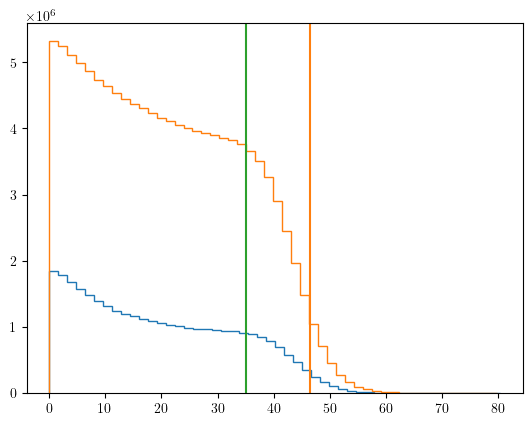

In [ ]:
Hist = plt.hist(np.abs(np.concatenate(rlos_t)), bins=50, histtype='step', density=False)
Hist = plt.hist(np.abs(np.concatenate(rlos_ls)), bins=50, histtype='step', density=False)
plt.axvline(np.max(rxhg), c='C1')
plt.axvline(35, c='C2') 

In [5]:
# compute histograms
bin_num = 50 
LOS_hists = np.zeros((bin_num, len(Mvirs), len(r_cens)))
#LOS_hists_t = np.zeros((bin_num, len(Mvirs), len(r_cens)))


for k in range(len(Mvirs)):
    for i in range(len(r_cens)):
        index = i + len(r_cens)*k

        if i <= 10:
            hist, vedges = np.histogram(vphyslos[index], bins=bin_num, range=[-4000, 4000], density=False)
            #hist_t, vedges = np.histogram(vphys_t[index], bins=bin_num, range=[-4000, 4000], density=False)
        else:
            hist, vedges = np.histogram(vphyslos_ls[index], bins=bin_num, range=[-4000, 4000], density=False)
        vcens = (vedges[:-1] + vedges[1:]) / 2 

        LOS_hists[:, k, i] = hist
        #LOS_hists_t[:, k, i] = hist_t  

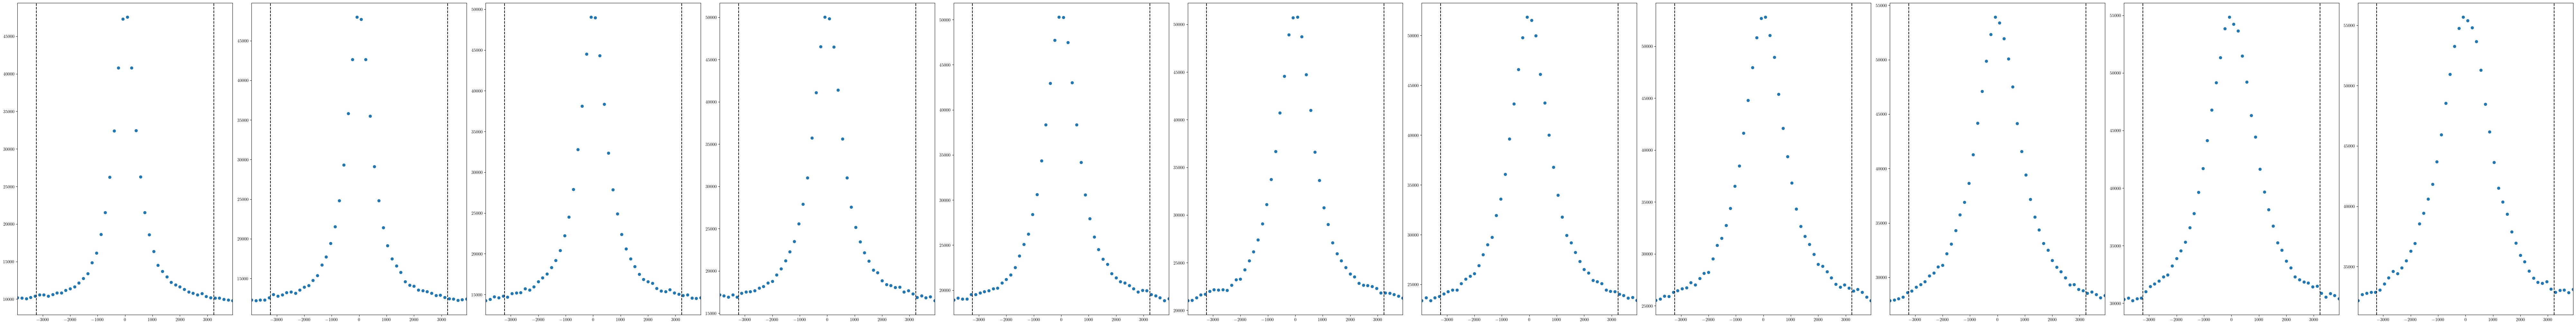

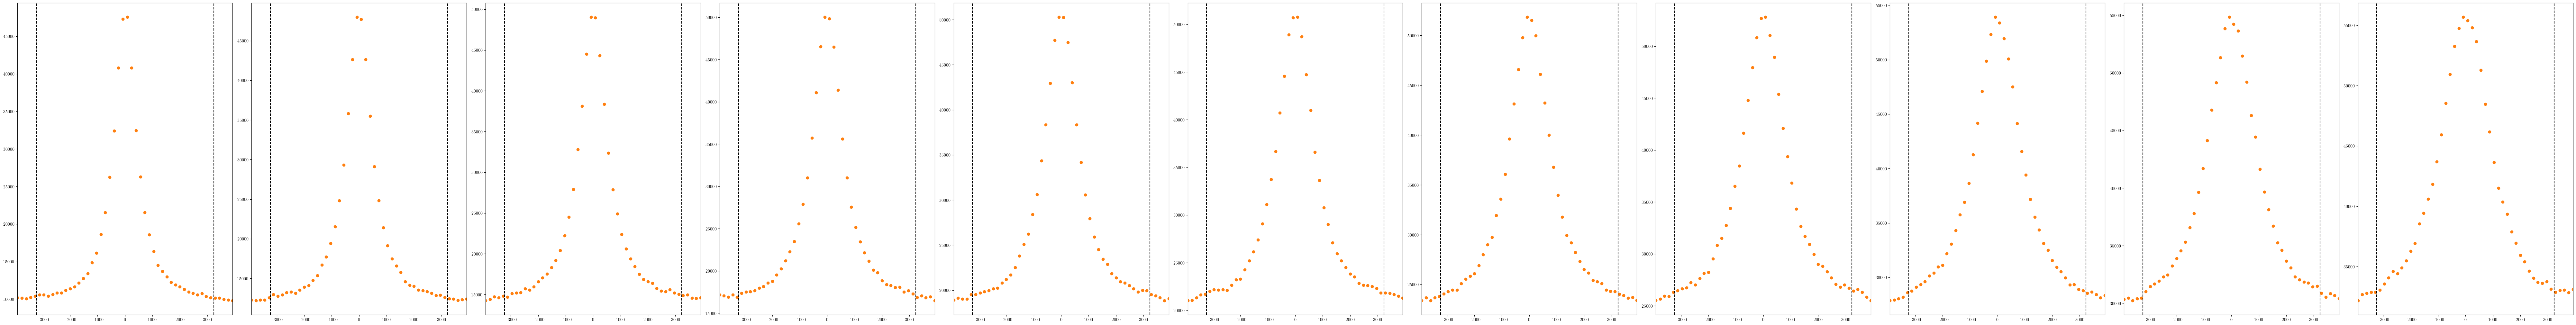

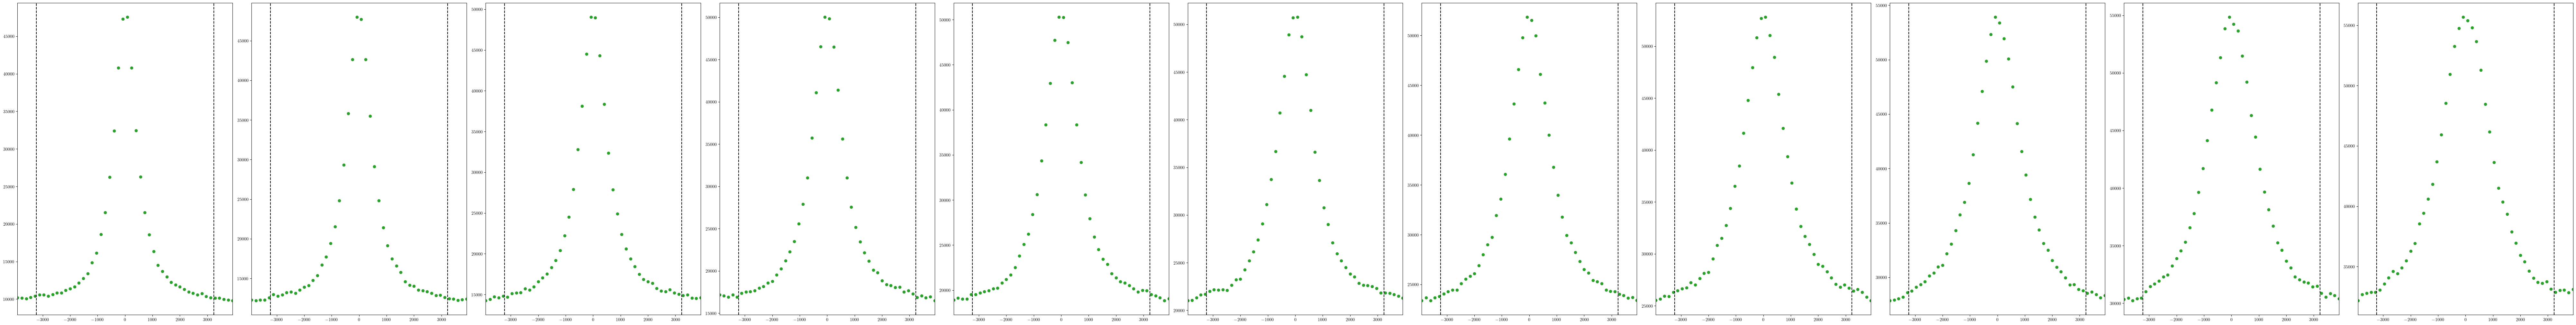

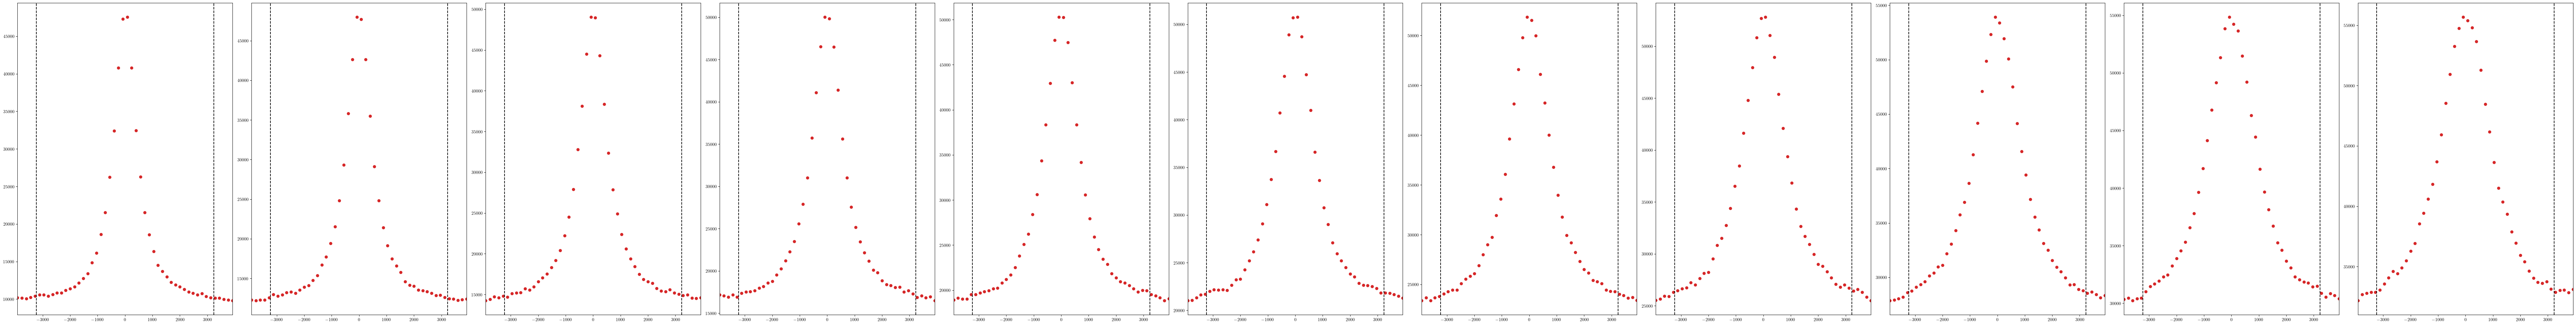

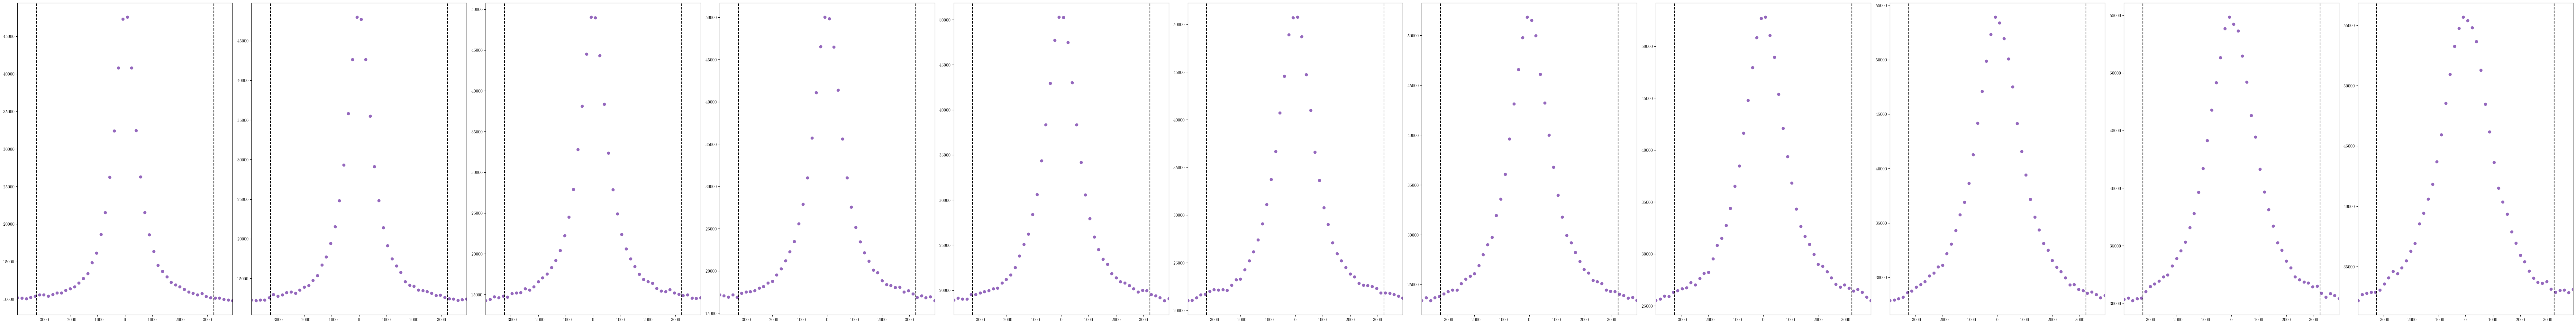

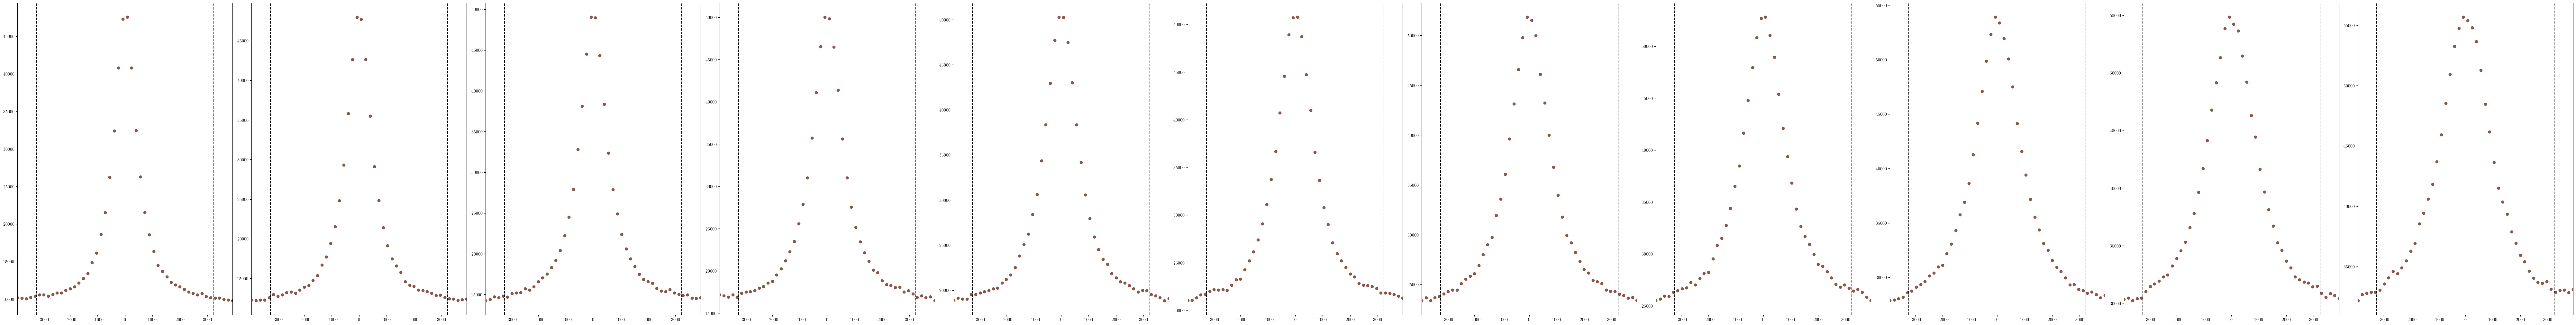

In [22]:
# validate my binning of Pvlos: things look good!
for k in range(len(Mvirs)):
    fig, ax = plt.subplots(1, len(r_cens[:11]), figsize=(80, 10), layout='constrained')

    for i in range(len(r_cens[:11])): 
        ax[i].scatter(vcens, LOS_hists[:, 0, i], c=f'C{str(k)}')
        ax[i].axvline(a*H*35/h, c='k', ls='--')
        ax[i].axvline(-a*H*35/h, c='k', ls='--')
        ax[i].margins(x=0)

In [5]:
rlos_edges = np.linspace(-80, 80, 1000+1)  #np.max(rxhg)
rlos_cens = 0.5*(rlos_edges[1:]+rlos_edges[:-1]) 
vpeclos, R_cens, rlos_cents, R_data, rlos_data = bin_velocities_abs_optimized('vz_pec', 'R/z', r_edges, rlos_edges, massbins=mbins[:2], return_rvals=True) #bins of R, r_los 
vphyslos_int, R_cens, rlos_cents, R_data, rlos_data = bin_velocities_abs_optimized('vlos', 'R/z', r_edges, rlos_edges, massbins=mbins[:2], return_rvals=True)

Number of bins: 26000
Number of bins: 26000


In [45]:
# bin LS as above 

#vpeclos_ls  = []

k = 0
for i, R in enumerate(r_cens):
        for j, rlos in enumerate(rlos_cens):
            if i <= 10:
                vpeclos_ls.append(np.array([0]))
            else:
                with h5.File(vel_path, 'r') as hdf:
                    rel_R = hdf[f'R/{str(k)}'][()]
                    rel_rlos = hdf[f'rlos/{str(k)}'][()]
                    vpec = hdf[f'vpeclos/{str(k)}'][()]

                mask = (rel_R >= r_edges[i]) & (rel_R <= r_edges[i+1]) & (rel_rlos >= rlos_edges[j]) & (rel_rlos <= rlos_edges[j+1])

                vpeclos_ls.append(vpec[mask]) 

KeyboardInterrupt: 

In [7]:
# define models, BF parameters


# pars
gal_MAP = np.array([ 1.98245745e+02,  5.53864658e-01,  5.72599594e-01,  3.94992883e-02,
        1.59549554e+05, -1.12290582e+00,  1.17453011e+00, -4.15201839e-01,
       -3.47438030e-02,  1.25418141e-01,  4.14120554e-05,  1.75603684e-01,
       -1.05049987e-01, -5.53158259e+02, -8.88081399e+02, -1.94343568e+01,
        4.77159076e+01,  2.77450696e+02, -1.14129239e+03])

part_MAP = np.array([ 1.89274827e+02,  5.83981117e-01,  7.47863822e-01, -1.33316764e-02,
  1.99611683e+05, -9.80959118e-01,  1.45001450e+00, -2.62303590e-01,
 -3.54686051e-02,  1.14008827e-01,  3.20841835e-05,  1.50276564e-01,
 -8.29957439e-02, -6.42615329e+02, -1.41167223e+03, -1.79471080e+01,
  1.19204199e+02,  2.82882901e+02, -1.07836598e+03])

cf_pars = [5.37569671e+00, 4.23001652e-01, 2.52267001e+00, 6.32218826e-02,
           2.89276487e+00, 4.40667100e-01, 3.83029496e-01, 2.98108140e+00,
           1.00202194e+00,]

# models

def plaw(x, p, s):
    """Power law function. 

    Args:
        x (any): power law argument 
        p (any): power law pivot
        s (any): power law slope
    """
    return p * x ** s


def marginal_radial_dist(vr, r, M, pars):
    """The smooth model for the marginal radial 
    distribution P(v_r|r, M). 

    This is a Johnson's SU distribution 
    (https://en.wikipedia.org/wiki/Johnson%27s_SU-distribution)
    which is reparameterized to take the 
    distribution peak and variance as 
    input, using an RBF interpolator. 

    Args:
        vr (np.ndarray): radial velocity bin centers. 
        r (float): radial distance bin center.
        M (float): Mass bin median.
    """

    vrpp, vrps, vrsp, vrss, srpp, srps, srsp, srss, delta_m, delta_b = pars

    # Mass dependence
    M_pivot = 1e14 # M_sun
    vr_p = -plaw( M / M_pivot, vrpp, vrps)
    vr_s = -plaw( M / M_pivot, vrsp, vrss)

    sr_p = plaw( M / M_pivot, srpp, srps)
    sr_s = -plaw( M / M_pivot, srsp, srss)

    r_pivot = 10 # radial pivot, 10 h^-1 Mpc

    sr_0 = 213027 # variance limit as r -> 00, km^2 s^-2

    # Radial dependence
    peak = plaw(r / r_pivot , vr_p, vr_s)
    variance = plaw(r / r_pivot, sr_p, sr_s) + sr_0  

    xi = xi_RBF(np.column_stack([peak, variance]))[0] # interpolators
    lam = lam_RBF(np.column_stack([peak, variance]))[0]

    gam = 0.00078 * xi + 0.58599 # JSU skew, kurtosis 
    delt = 0.00209 * lam + 0.28703 + line(M / M_pivot, delta_m, delta_b)

    dist = johnsonsu.pdf(vr, a=gam, b=delt, loc=xi, scale=lam)

    return dist


def line(x,m,b):
    return m*x+b

def conditional_tangential_dist(vt, vr, r, M, pars):
    """The smooth model for the conditional tangential 
    velocity distribution P(v_t|v_r, r, M). 

    This is a Student's t distribution with a fixed 
    degree of freedom (dof) parameter characterizing 
    the kurtosis of the distribution. The remaining 
    dependences are captured in the variance. 

    Args:
        v_t (np.ndarray): tangential velocity bin centers.
        v_r (_type_): radial velocity bin center.
        r (_type_): radial distance bin center.
        M (float): Mass bin median.
        pars (_type_): parameters defining the radial dependence.
    """

    s_c, s_qm, s_qb, s_mmm, s_mmb, s_mbm, s_mbb, s_0mm, s_0mb = pars

    dof = 5 # degrees of freedom, "shape" parameter
    s_0p = 48 # h^-1 Mpc, transition of sigma_vt^2 minimum to a constant
    s_0c = 105_000 # km^2 s^-2, minimum value as r -> 00 
    
    M_pivot = 1e14 # M_sun

    # Mass dependence 
    s_q = plaw( M / M_pivot, s_qm, s_qb)
    s_mm = line( M / M_pivot, s_mmm, s_mmb)
    s_mb = line( M / M_pivot, s_mbm, s_mbb)
    s_0m = line( M / M_pivot, s_0mm, s_0mb)

    s_m = s_mm / r + s_mb
    s_0 = s_0m * np.log( 1 + np.exp( - (r - s_0p))) + s_0c 

    if vr > -2_000:
        variance = s_c * ( vr - s_m ) ** 3 + s_q * ( vr - s_m ) ** 2 + s_0
    else:
       test_vr = np.linspace(-2000, -1000, 100)
       p, _ = curve_fit(line, test_vr, s_c * ( test_vr - s_m ) ** 3 + s_q * ( test_vr - s_m ) ** 2 + s_0)
       variance = line(vr, p[0], p[1]) #s_c * ( vr - s_m ) ** 3 + s_q * ( vr - s_m ) ** 2 + s_0 #s_q * ( vr - s_m ) ** 2 + s_0
        # plt.plot(test_vr, line(test_vr, p[0], p[1])) 
        # plt.plot(test_vr, s_c * ( test_vr - s_m ) ** 3 + s_q * ( test_vr - s_m ) ** 2 + s_0)
    scale = np.sqrt( variance )

    dist = t.pdf(vt, df=dof, scale=scale)

    return dist

def joint_dist(vr, vt, r, M, pars):
    """The smooth model for the joint distribution
    P(v_r, v_t | r, M). 

    This is the product of the marginal 
    radial velocity distribution and the 
    conditional tangential velocity 
    distribution:
    
    P(v_r, v_t | r, M) = P(v_r | r, M)P(v_t | v_r, r, M)  

    Args:
        v_r (np.ndarray): radial velocity bin centers. 
        v_t (np.ndarray): tangential velocity bin centers.
        r (float): radial distance bin center.
        pars (np.ndarray): parameters defining radial dependence.
    """

    vrpp, vrps, vrsp, vrss, srpp, srps, srsp, srss, delta_m, delta_b, \
        s_c, s_qm, s_qb, s_mmm, s_mmb, s_mbm, s_mbb, s_0mm, s_0mb = pars


    marg_rad = marginal_radial_dist(vr, r, M, [vrpp, vrps, vrsp, vrss, srpp, srps, srsp, srss, delta_m, delta_b])

    if vr.size <= 1 or np.isscalar(vr):
        con_tan = conditional_tangential_dist(vt, vr, r, M, [s_c, s_qm, s_qb, s_mmm, s_mmb, s_mbm, s_mbb, s_0mm, s_0mb])

        jd = marg_rad * con_tan.T 

        return jd 

    else:
        con_tan = np.array([conditional_tangential_dist(vt, v, r, M, [s_c, s_qm, s_qb, s_mmm, s_mmb, s_mbm, s_mbb, s_0mm, s_0mb]) for v in vr ])

        jd = marg_rad * con_tan.T 

        norm = np.trapz(np.trapz(jd, vr, dx=np.diff(vr)[0], axis=-2), vt, dx=np.diff(vt)[0], axis=-1)

        return jd / norm
    
def P_vlos_R_rlos(vlos, R, r_los, M, pars):
    """
    Compute P(v_los | R, r_los) by numerically integrating over the joint distribution.

    Args:
        vlos (np.ndarray): 
            Line-of-sight velocity bin centers.
        R (float): 
            Projected radius.
        r_los (float): 
            Line-of-sight distance.
        M (float): 
            Halo mass.
    
    Returns:
        P_vlos (np.ndarray): 
            Probability density evaluated at each v_los bin center. 
    """
    vr = np.linspace(-15_000, 15_000, 1000)#np.copy(vlos)
    vt = np.copy(vr) 

    # distance relations
    theta = np.arctan2(R, r_los)
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    r = np.sqrt(R**2 + r_los**2) 

    JD = joint_dist(vr, vt, r, M, pars)
    #JD = np.nan_to_num(JD, nan=0.0) 
    #print(np.sum(np.isnan(JD))/len(JD.flatten()))

    # Interpolation function for fast lookups
    JD_interp = RectBivariateSpline(vr, vt, JD)

    # Create output array
    P_out = np.zeros_like(vlos)

    # Integral: for each vlos, integrate over vr
    for i, v in enumerate(vlos):
        # Compute vt value corresponding to each vr
        vt_eval = (v - vr * sin_theta) / cos_theta
        integrand = JD_interp.ev(vr, vt_eval) / cos_theta
        P_out[i] = np.trapz(integrand, vr)

    return P_out / P_out.sum() / np.diff(vlos)[0]


full_r2d = np.logspace(np.log10(min(rxhg)), np.log10(60), 1000)
zel2d = np.fromfile('/spiff/cosweeney/simulations/MDPL2/data/CorrFuncs/zel2d')

r_dict = {value: index for index, value in enumerate(rxhg)}

rvals = np.logspace(np.log10(0.1), np.log10(80), 1000)
zel2d = np.fromfile('/spiff/cosweeney/simulations/MDPL2/data/CorrFuncs/zel_LS_final')

r_dict = {value: index for index, value in enumerate(rxhg)}

def find_closest_zel_hg(r):
    r_points = rvals
    zel_hg_points = zel2d
    # Ensure r is within the range of r_points
    if r > r_points[-1]:
        return 0.0

    # Find the index of the closest point in r_points
    closest_index = np.argmin(np.abs(r_points - r))

    # Get the corresponding zel_hg value
    closest_zel_hg = zel_hg_points[closest_index]

    return closest_zel_hg


def cf_inf(r, M, params):
    b_p, b_s, g_p, g_s, c0, c_m, c_sig, r_inf, mu = params

    # constants
    M_vp = 1e14 # h^-1 M_sun
    B = 0.948 # offset
    r_h = (7.35305605e-01)*(M/1e14)**(2.80615822e-01) # From total hg fit

    # mass dependence
    b = b_p*(M/M_vp)**b_s
    g = g_p*(M/M_vp)**g_s
    c = c0*(1 - scipy.special.erf( (np.log10(M/M_vp) - c_m) / c_sig )  ) / 2

    x = r / r_h

    # Interpolate zel_xhg to match r
    zel_interp = np.interp(r, rvals, zel2d)

    if np.isscalar(r):
        zel = find_closest_zel_hg(r)
        corr_inf1 = b*( ( 1 + ( r_inf / ( mu*r_h + r ) )**g ) / ( 1 + c * x * np.exp( -x ) ) )*B*zel 
        return corr_inf1
    else:
        corr_inf = b*( ( 1 + ( r_inf / ( mu*r_h + r ) )**g ) / ( 1 + c * x * np.exp( -x ) ) )*B*zel_interp
        return corr_inf
    
def surf_int_inf(rlos, R, M, params):
    b_p, b_s, g_p, g_s, c0, c_m, c_sig, r_inf, mu = params
    r3d   = np.sqrt(rlos**2 + R**2)

    a = 0.83760
    redshift=1/a-1
    h=cosmo.h
    H = h*100*cosmo.Ez(redshift)

    v_max = 4_000
    sigma = 532 

    return 0.014*(cf_inf(r3d, M, [b_p, b_s, g_p, g_s, c0, c_m, c_sig, r_inf, mu]) + 1)*( scipy.special.erf( (v_max - a*H*rlos/h)/ np.sqrt(2) / sigma ) + 1)

def Sigma_inf(R, M, params):
    b_p, b_s, g_p, g_s, c0, c_m, c_sig, r_inf, mu = params

    if np.isscalar(R): #np.sqrt(60**2 - R**2)
        return quad_vec(surf_int_inf, 0, 60, args=(R, M, [ b_p, b_s, g_p, g_s, c0, c_m, c_sig, r_inf, mu ]), workers=-1)[0]
    else:
        inte = np.array([np.array([quad_vec(surf_int_inf, 0, 60, args=(R[i], M, h, [ b_p, b_s, g_p, g_s, c0, c_m, c_sig, r_inf, mu ]), workers=-1)[0] ]) for i in range(len(R))]).T
        return inte[0]


def P_vphys_R_vec(v_phys, R, M, pars):
    M = M * 1e14

    h = cosmo.h
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)

    # r_LOS integration range
    rlos_max = 60 #60 #100 #np.sqrt(60**2 - R**2)
    rlos_vals = np.linspace(-rlos_max, rlos_max, 100)

    # Shape (n_v, n_r)
    vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 

    # velocity grid for interpolation
    vr_grid = np.linspace(-np.max(vpec), np.max(vpec), 100) 

    # Compute P(vlos | R, rlos) for all rlos on vr_grid
    Pvlos_grid = np.array([P_vlos_R_rlos(vr_grid, R, rlos, M, pars) for rlos in rlos_vals])  
    # shape (n_r, n_v)

    # Interpolate along vr_grid axis for each rlos
    Pvlos_interp = np.array([
        np.interp(vpec[:, j], vr_grid, Pvlos_grid[j], left=None, right=None)
        for j in range(len(rlos_vals))
    ])  # shape (n_r, n_v)

    # Now shape (n_v, n_r)
    Pvlos_interp = Pvlos_interp.T  

    # Weight factor
    weight = 0.014 * (cf_inf(np.sqrt(R**2 + rlos_vals**2), M, cf_pars) + 1)  
    # shape (n_r,)

    # Multiply and integrate over rlos
    integrand = Pvlos_interp * weight[None, :]  
    P_out = np.trapz(integrand, rlos_vals, axis=1)  # shape (n_v,)

    # Normalize by Sigma(R)
    sigma_R = Sigma_inf(R, M, cf_pars)
    P_out /= sigma_R

    # Symmetrize
    dist = P_out #+ np.flip(P_out)

    return dist / dist.sum() / np.diff(v_phys)[0]

(-15000.0, 15000.0)

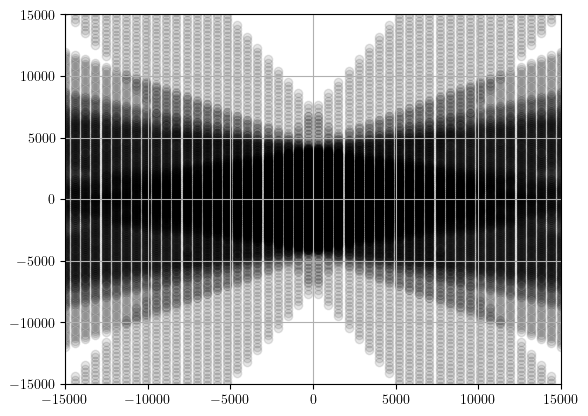

In [12]:
# can we do without the interpolation in the functions above?

#def test_Pvlos_R_rlos(vlos, R, rlos):

R = 10 # h^-1 Mpc
rlos_grid = np.linspace(-60, 60, 10)
theta = np.arctan2(R, rlos_grid)
cos_theta = np.cos(theta)
sin_theta = np.sin(theta)

vlos_grid = np.linspace(-4000, 4000, 50)

vr_grid = np.linspace(-15_000, 15_000, 50)
vt_grid = vr_grid

Vr, Vt = np.meshgrid(vr_grid, vt_grid)

vts = []
for i, rlos in enumerate(rlos_grid):
    for j, vlos in enumerate(vlos_grid):
        vt_eval = (vlos - vr_grid*sin_theta[i])/cos_theta[i]
        vts.append(vt_eval)
        plt.scatter(vr_grid, vt_eval, alpha=0.1, c='k')

plt.grid()
plt.ylim((-15_000, 15_000))
plt.xlim((-15_000, 15_000))


/tmp/ipykernel_1524031/2533993146.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(np.trapz(jd, vr, dx=np.diff(vr)[0], axis=-2), vt, dx=np.diff(vt)[0], axis=-1)
/tmp/ipykernel_1524031/2533993146.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out[i] = np.trapz(integrand, vr)
/tmp/ipykernel_1524031/4160165628.py:42: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out[i] = np.trapz(integrand, vr)


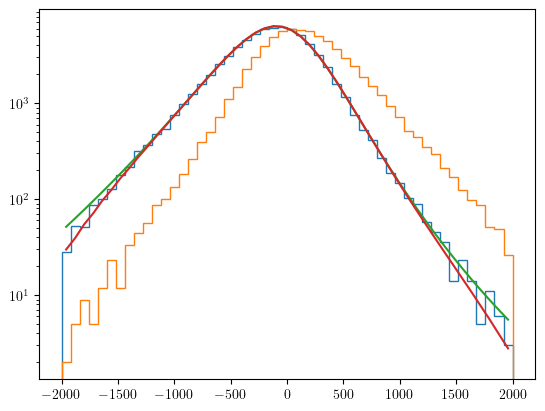

In [9]:
def P_vlos_R_rlos_noint(vlos, R, r_los, M, pars):
    """
    Compute P(v_los | R, r_los) with manual linear interpolation.
    """
    vr = np.copy(vlos)#
    vt = np.copy(vr) 
    
    theta = np.arctan2(R, r_los)
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    r = np.sqrt(R**2 + r_los**2) 
    
    JD = joint_dist(vr, vt, r, M, pars)
    P_out = np.zeros_like(vlos)
    
    for i, v in enumerate(vlos):
        vt_eval = (v - vr * sin_theta) / cos_theta
        
        # Find bracketing indices for linear interpolation
        indices_right = np.searchsorted(vt, vt_eval)
        indices_left = indices_right - 1
        
        # Initialize integrand
        integrand = np.zeros_like(vr)
        
        # Mask for valid interpolation (within grid bounds)
        valid = (indices_right > 0) & (indices_right < len(vt))
        
        if np.any(valid):
            # Linear interpolation weights
            vt_left = vt[indices_left[valid]]
            vt_right = vt[indices_right[valid]]
            weight_right = (vt_eval[valid] - vt_left) / (vt_right - vt_left)
            weight_left = 1.0 - weight_right
            
            # Interpolated values
            vr_indices = np.arange(len(vr))[valid]
            JD_left = JD[vr_indices, indices_left[valid]]
            JD_right = JD[vr_indices, indices_right[valid]]
            integrand[valid] = (weight_left * JD_left + weight_right * JD_right) / cos_theta
        
        P_out[i] = np.trapz(integrand, vr)
    
    return P_out / P_out.sum() / np.diff(vlos)[0]

def P_vlos_R_rlos_noint2(vlos, R, r_los, M, pars):
    """
    Compute P(v_los | R, r_los) by numerically integrating over the joint distribution.
    
    Args:
        vlos (np.ndarray): 
            Line-of-sight velocity bin centers.
        R (float): 
            Projected radius.
        r_los (float): 
            Line-of-sight distance.
        M (float): 
            Halo mass.
            
    Returns:
        P_vlos (np.ndarray): 
            Probability density evaluated at each v_los bin center. 
    """
    # Distance relations
    theta = np.arctan2(r_los, R)
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    r = np.sqrt(R**2 + r_los**2)
    
    # Compute all required vt values
    # For each vlos and vr combination, we need vt = (vlos - vr * sin_theta) / cos_theta
    vt_required_list = []
    for v in vlos:
        vt_for_this_vlos = (v - vlos * sin_theta) / cos_theta
        vt_required_list.append(vt_for_this_vlos)
    
    # Create expanded grids - both same length
    vr_expanded = np.copy(vlos)
    vt_all_values = np.concatenate([vlos] + vt_required_list)
    vt_expanded = np.unique(vt_all_values)
    vt_expanded = np.sort(vt_expanded)
    
    # Make vr_expanded same length as vt_expanded by extending the grid
    # We need both grids to span the required ranges
    vr_min, vr_max = vr_expanded[0], vr_expanded[-1]
    vt_min, vt_max = vt_expanded[0], vt_expanded[-1]
    
    # Create uniform grids that cover both ranges with same number of points
    n_points = max(len(vr_expanded), len(vt_expanded))
    vr_grid = np.linspace(vr_min, vr_max, n_points)
    vt_grid = np.linspace(vt_min, vt_max, n_points)
    
    # Evaluate joint distribution on the uniform grid
    # JD will be shape (n_points, n_points)
    JD = joint_dist(vr_grid, vt_grid, r, M, pars)
    
    # Create output array
    P_out = np.zeros_like(vlos)
    
    # For each vlos, integrate over vr
    for i, v in enumerate(vlos):
        # Compute vt values corresponding to each vr on the grid
        vt_eval = (v - vr_grid * sin_theta) / cos_theta
        
        # Find closest indices in vt_grid for each vt_eval
        indices = np.searchsorted(vt_grid, vt_eval)
        indices = np.clip(indices, 0, len(vt_grid) - 1)
        
        # For better accuracy, adjust to closest point
        for j in range(len(indices)):
            if indices[j] > 0:
                if abs(vt_grid[indices[j]] - vt_eval[j]) > abs(vt_grid[indices[j]-1] - vt_eval[j]):
                    indices[j] -= 1
        
        # Extract JD values at (vr_grid[j], vt_grid[indices[j]])
        integrand = JD[np.arange(len(vr_grid)), indices] / cos_theta
        
        # Integrate using trapezoidal rule
        P_out[i] = np.trapz(integrand, vr_grid)
    
    # Normalize
    return P_out / P_out.sum() / np.diff(vlos)[0]

test1 = P_vlos_R_rlos(vcens, R=r_cens[10], r_los=rlos_cens[600], M=Mvirs[0], pars=gal_MAP)
test2 = P_vlos_R_rlos_noint(vcens, R=r_cens[10], r_los=rlos_cens[600], M=Mvirs[0], pars=gal_MAP)
#test3 = P_vlos_R_rlos_noint2(vcens, R=r_cens[6], r_los=rlos_cens[600], M=Mvirs[0], pars=gal_MAP)


test_hist = plt.hist(np.concatenate(vpeclos[590+10*1000:610+10*1000]), bins=vedges,density=False, histtype='step')
test_hist2 = plt.hist(-np.concatenate(vpeclos[590+10*1000:609+10*1000]), bins=vedges,density=False, histtype='step')

plt.plot(vcens, np.sum(test_hist[0])*test1*np.diff(vcens)[0])
plt.plot(vcens, np.sum(test_hist[0])*test2*np.diff(vcens)[0])
#plt.plot(vcens, test3)

plt.yscale('log')

In [22]:
r_cens[10]

np.float64(14.5)

In [25]:
rlos_cens[600]

np.float64(12.059999999999995)

/tmp/ipykernel_3902160/473600261.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.plot(vcens, (np.sum(test_hist[0])*test1*np.diff(vcens)[0]-test_hist[0])/np.sqrt(test_hist[0]))
/tmp/ipykernel_3902160/473600261.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.plot(vcens, (np.sum(test_hist[0])*test2*np.diff(vcens)[0]-test_hist[0])/np.sqrt(test_hist[0]))


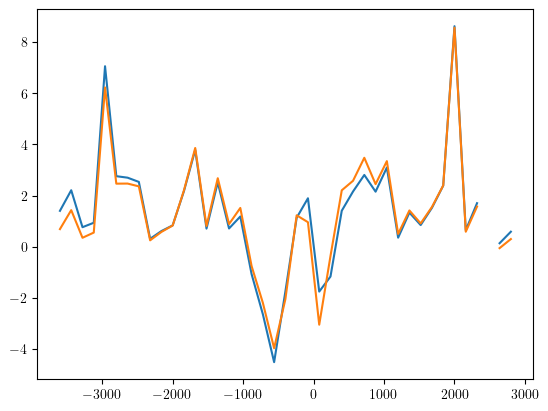

In [29]:
plt.plot(vcens, (np.sum(test_hist[0])*test1*np.diff(vcens)[0]-test_hist[0])/np.sqrt(test_hist[0]))
plt.plot(vcens, (np.sum(test_hist[0])*test2*np.diff(vcens)[0]-test_hist[0])/np.sqrt(test_hist[0])) 
#plt.ylim((-0.5, 0.5))

In [31]:
res = (np.sum(test_hist[0])*test1*np.diff(vcens)[0]-test_hist[0])/np.sqrt(test_hist[0])
np.mean(res[~np.isinf(res)])

/tmp/ipykernel_3902160/776649728.py:1: RuntimeWarning: divide by zero encountered in divide
  res = (np.sum(test_hist[0])*test1*np.diff(vcens)[0]-test_hist[0])/np.sqrt(test_hist[0])


np.float64(1.3249454185414116)

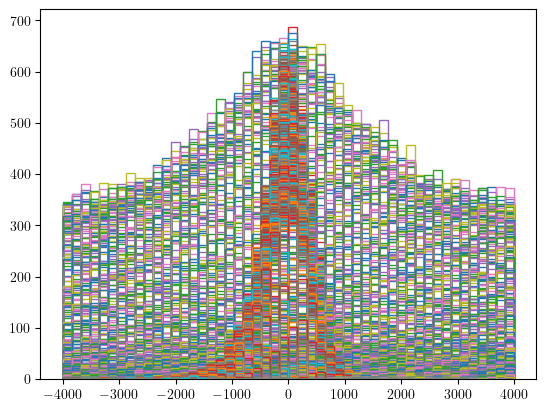

In [138]:
#test1 = P_vlos_R_rlos(vcens, R=r_cens[6], r_los=rlos_cens[600], M=Mvirs[0], pars=gal_MAP)
#test2 = P_vlos_R_rlos_noint(vcens, R=r_cens[6], r_los=rlos_cens[600], M=Mvirs[0], pars=gal_MAP)
#test3 = P_vlos_R_rlos_noint2(vcens, R=r_cens[6], r_los=rlos_cens[600], M=Mvirs[0], pars=gal_MAP)
hists = np.zeros((1000, 50))
pec_hists = np.zeros((1000, 50))
cs = np.zeros((1000, 50))

areas = np.zeros(1000)
for i in range(1000):
    test_hist, _, _ = plt.hist(vphyslos_int[i+10*1000], bins=vedges,density=False, histtype='step')
    test_hist2, _, _ = plt.hist(vpeclos[i+10*1000], bins=vedges,density=False, histtype='step')

    cumsum = np.cumsum(test_hist)*np.diff(vcens)[0]
    cs[i] = cumsum
    # if cumsum[-2] < 0.999:
    #     test_hist = test_hist * (1 - cumsum[-1])
    areas[i] = np.sum(test_hist)
    hists[i] = test_hist
    pec_hists[i] = test_hist2

#plt.plot(vcens, test1)

In [ ]:
plt.hist(vpeclos[i+10*1000], bins=vedges,density=False, histtype='step') 

In [107]:
cs[900][-1]

np.float64(1.0)

0.0


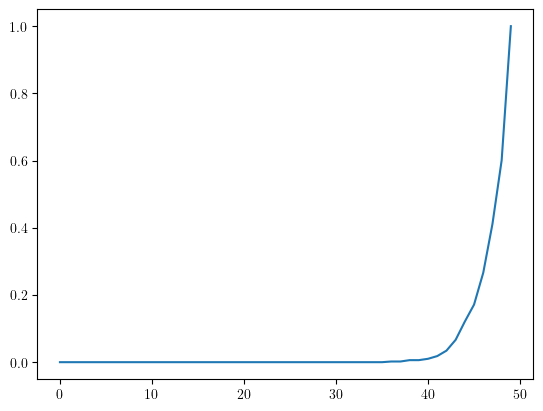

In [110]:
print((cs[500][-1]-cs[500][-2])/(vcens[-1]-vcens[-2]))
plt.plot(cs[900]-cs[900][0]) 

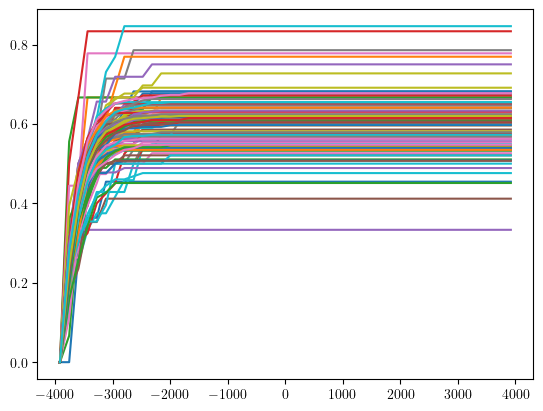

In [102]:
for i in range(100):
    #if cs[i][-2] < 0.999:
    plt.plot(vcens, cs[i]-cs[i][0])

#plt.yscale('log')

(array([   5.,   21.,   91.,  676., 1755.,  367.,   63.,    9.,    3.,
           2.]),
 array([-2448.92211914, -1886.63989258, -1324.35766602,  -762.07543945,
         -199.79321289,   362.48901367,   924.77124023,  1487.0534668 ,
         2049.33569336,  2611.61791992,  3173.90014648]),
 <BarContainer object of 10 artists>)

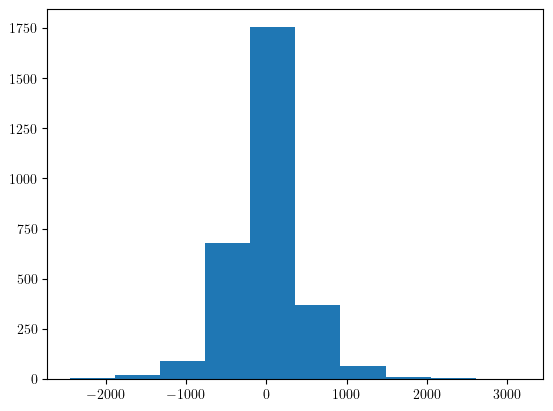

In [125]:
plt.hist(vpeclos[500])

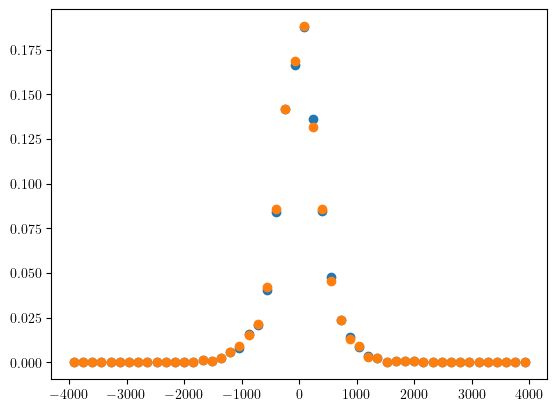

In [126]:
plt.scatter(vcens, hists[500]/np.sum(hists[500])) 
plt.scatter(vcens, pec_hists[500]/np.sum(pec_hists[500]))  

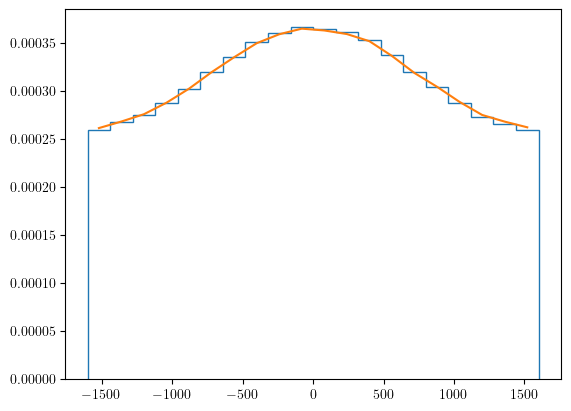

In [148]:
#hists = hists / np.sum(pec_hists, axis=1)[:, np.newaxis] / np.diff(vcens)[0] 

rs = np.sqrt(r_cens[10]**2+rlos_cens**2)
dist = np.sum(hists*np.diff(vcens)[0]*(0.014*(cf_inf(rs, Mvirs[0], cf_pars)[:, np.newaxis]+1)), axis=0) / Sigma_inf(r_cens[10], Mvirs[0], cf_pars)
dist = dist/np.sum(dist[15:-15]*np.diff(vcens)[0])
phist, _, _ = plt.hist(vphyslos[10], bins=vedges[15:-15], density=True, histtype='step')
plt.plot(vcens[15:-15], dist[15:-15]) 

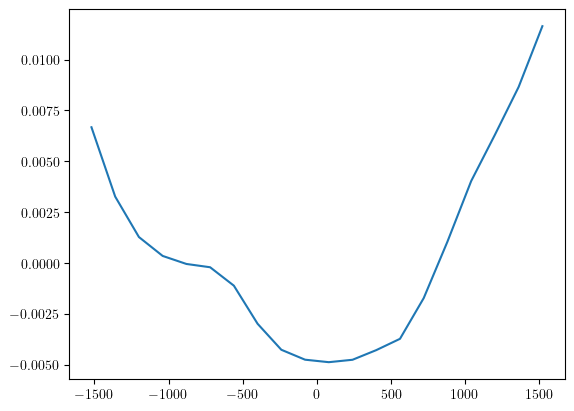

In [150]:
plt.plot(vcens[15:-15], (dist[15:-15]-phist)/phist)

In [98]:
rlos_edges_red = np.linspace(-60, 60, 60+1)  #np.max(rxhg)
rlos_cens_red = 0.5*(rlos_edges_red[1:]+rlos_edges_red[:-1]) 

def P_vphys_R_vec_noint(v_phys, R, M, pars):
    M = M * 1e14
    h = 0.677 #cosmo.h 
    a = 0.83760
    redshift = 1/a - 1
    H = h * 100 * cosmo.Ez(redshift)
    rlos_vals = rlos_cens_red
    vpec_data_max = np.max(v_phys)
    v_buffer = 500
    vr_e = np.linspace(-vpec_data_max - v_buffer, vpec_data_max + v_buffer, 50+1)
    vr_grid = 0.5 * (vr_e[1:] + vr_e[:-1])
    vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 
    
    # Compute P(vlos | R, rlos) for each rlos
    Pvlos_grid = np.array([P_vlos_R_rlos_noint(vr_grid, R, rlos, M, pars) for rlos in rlos_vals])  
    
    # Manual linear interpolation for each rlos
    Pvlos_interp_list = []
    for j in range(len(rlos_vals)):
        vpec_j = vpec[:, j]
        
        # Find bracketing indices for linear interpolation
        indices_right = np.searchsorted(vr_grid, vpec_j)
        indices_left = indices_right - 1
        
        # Initialize interpolated values
        interpolated = np.zeros_like(vpec_j)
        
        # Mask for valid interpolation (within grid bounds)
        valid = (indices_right > 0) & (indices_right < len(vr_grid))
        
        if np.any(valid):
            # Get bracketing grid points
            vr_left = vr_grid[indices_left[valid]]
            vr_right = vr_grid[indices_right[valid]]
            
            # Get bracketing probability values
            P_left = Pvlos_grid[j, indices_left[valid]]
            P_right = Pvlos_grid[j, indices_right[valid]]
            
            # Compute interpolation weights
            weight_right = (vpec_j[valid] - vr_left) / (vr_right - vr_left)
            weight_left = 1.0 - weight_right
            
            # Linear interpolation
            interpolated[valid] = weight_left * P_left + weight_right * P_right
        
        # Values outside grid bounds are already zero
        Pvlos_interp_list.append(interpolated)
    
    Pvlos_interp = np.array(Pvlos_interp_list)
    Pvlos_interp = Pvlos_interp.T 
    
    # Integration using Simpson's rule (manual implementation)
    r3d = np.sqrt(R**2 + rlos_vals**2)
    weight = 0.014 * (cf_inf(r3d, M, cf_pars) + 1)
    integrand = Pvlos_interp * weight[None, :]
    
    # Manual Simpson's rule
    # Simpson's rule: integral ≈ (h/3) * [f0 + 4*f1 + 2*f2 + 4*f3 + ... + fn]
    n = len(rlos_vals)
    h = np.diff(rlos_vals)[0] if len(np.unique(np.diff(rlos_vals))) == 1 else None
    
    if h is not None and n % 2 == 1:
        # Standard Simpson's rule for uniformly spaced points
        coeffs = np.ones(n)
        coeffs[1:-1:2] = 4  # Odd indices
        coeffs[2:-1:2] = 2  # Even indices
        P_out = (h / 3) * np.sum(integrand * coeffs[None, :], axis=1)
    else:
        # Fall back to trapezoidal rule for non-uniform or even-length grids
        P_out = np.trapz(integrand, x=rlos_vals, axis=1)
    
    sigma_R = Sigma_inf(R, M, cf_pars)
    P_out /= sigma_R
    dv = np.diff(v_phys)[0]
    
    return P_out / np.sum(P_out * dv)

In [7]:
import warnings
warnings.filterwarnings("ignore")

In [99]:
#test = P_vphys_R_vec(vcens, r_cens[10], Mvirs[0]/1e14, pars=gal_MAP)
test_1 = P_vphys_R_vec_noint(vcens, r_cens[10], Mvirs[0]/1e14, pars=gal_MAP)

/tmp/ipykernel_3684315/1970218332.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(np.trapz(jd, vr, dx=np.diff(vr)[0], axis=-2), vt, dx=np.diff(vt)[0], axis=-1)
/tmp/ipykernel_3684315/439503512.py:42: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out[i] = np.trapz(integrand, vr)
/tmp/ipykernel_3684315/3430365064.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out = np.trapz(integrand, x=rlos_vals, axis=1)


In [21]:
len(vpeclos)

26000

In [105]:
test_2 = P_vphys_R_fromhists(vcens, 10, 0)

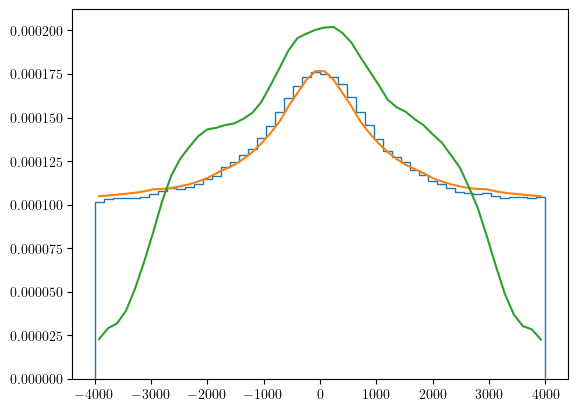

In [106]:
hist, _, _ = plt.hist(vphyslos[10], bins=vedges, density=True, histtype='step')
#plt.plot(vcens, test)
plt.plot(vcens, test_1)
plt.plot(vcens, test_2)
#plt.plot(vcens, test_1-(test_1[-5]-hist[-5]))

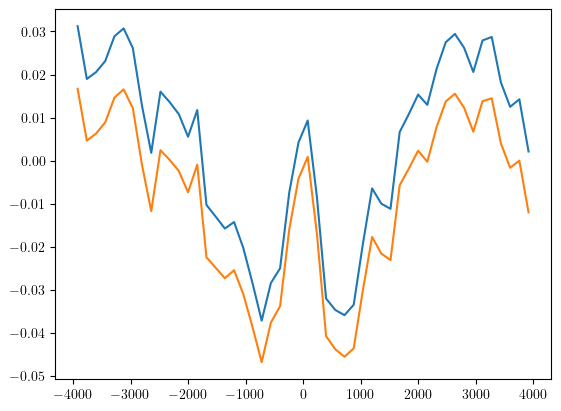

In [74]:
plt.plot(vcens, (test_1-hist)/hist)
plt.plot(vcens, (test_1-(test_1[-2]-hist[-2])-hist)/hist)

In [ ]:
# check integration routine. Does integrating histograms give the correct result?

def P_vphys_R_fromhists(v_phys, R_ind, M_ind):
    R = r_cens[R_ind]
    M = Mvirs[M_ind] # * 1e14

    h = cosmo.h
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)

    # r_LOS integration range
    #rlos_max = 100 #np.sqrt(max(rxhg)**2 - R**2)
    rlos_vals = rlos_cens #np.linspace(0.0, rlos_max, 100)

    # velocity grid for interpolation
    vr_e = np.linspace(-4000, 4000, 100+1)
    vr_grid = 0.5*(vr_e[1:]+vr_e[:-1]) 

    # Shape (n_v, n_r)
    vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 
    
    # Compute P(vlos | R, rlos) for all rlos on vr_grid
    Pvlos_grid = np.array([np.histogram(vpeclos[ind + R_ind*len(rlos_cens) + M_ind*len(r_cens)*len(rlos_cens)], #- a*H*rlos_data[ind + R_ind*len(rlos_cens) + M_ind*len(r_cens)*len(rlos_cens)]/h, 
                                        bins=vr_e, 
                                        #range=[-4000, 4000], 
                                        density=True)[0] for ind in range(len(rlos_cens))])

    #print(vr_grid.shape, Pvlos_grid.shape)
    #np.array([P_vlos_R_rlos(vr_grid, R, rlos, M, pars) for rlos in rlos_vals])  
    # shape (n_r, n_v)

    # Interpolate along vr_grid axis for each rlos
    Pvlos_interp = np.array([
         np.interp(vpec[:, j], vr_grid, Pvlos_grid[j], left=None, right=None)
         for j in range(len(rlos_vals))
     ])  # shape (n_r, n_v)

    # Now shape (n_v, n_r)
    Pvlos_interp = Pvlos_interp.T
    #Pvlos_interp = Pvlos_grid.T #Pvlos_interp.T  
    #Pvlos_interp = np.nan_to_num(Pvlos_interp)
    #print(np.sum(np.isnan(Pvlos_interp))/len(Pvlos_interp.flatten()))
    #print(Pvlos_interp.shape)

    # Weight factor
    weight = 0.014 * (cf_inf(np.sqrt(R**2 + rlos_vals**2), M, cf_pars) + 1)  
    # shape (n_r,)

    # Multiply and integrate over rlos
    integrand = Pvlos_interp * weight[None, :]  
    P_out = np.trapezoid(integrand, rlos_vals, axis=1)  # shape (n_v,)

    # Normalize by Sigma(R)
    sigma_R = Sigma_inf(R, M, h, cf_pars)
    P_out /= sigma_R

    # Symmetrize
    #dist = P_out + np.flip(P_out)

    return dist / dist.sum() / np.diff(v_phys)[0]

test = P_vphys_R_fromhists(vcens, 10, 0)

In [37]:
# how does claude do?

rlos_edges_red = np.linspace(-60, 60, 60+1)  #np.max(rxhg)
rlos_cens_red = 0.5*(rlos_edges_red[1:]+rlos_edges_red[:-1]) 


def P_vphys_R_fromhists(v_phys, R_ind, M_ind):
    R = r_cens[R_ind]
    M = Mvirs[M_ind] # * 1e14

    h = cosmo.h 
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)

    rlos_vals = rlos_cens_red

    vpec_data_max = 4000.0

    v_buffer = 500
    vr_e = np.linspace(-vpec_data_max - v_buffer, vpec_data_max + v_buffer, 100+1)
    vr_grid = 0.5*(vr_e[1:]+vr_e[:-1])

    vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 

    vels = vpeclos

    Pvlos_grid = []
    for ind in range(len(rlos_cens)):
        vel_data = vels[ind + R_ind*len(rlos_cens) + M_ind*len(r_cens)*len(rlos_cens)]
        
        # Count histogram
        hist, _ = np.histogram(vel_data, bins=vr_e, density=True)

        
        Pvlos_grid.append(hist)

    Pvlos_grid = np.array(Pvlos_grid)
    Pvlos_grid = np.nan_to_num(Pvlos_grid, 0.0)
    print(np.sum(np.isnan(Pvlos_grid))/len(Pvlos_grid.flatten()))


    from scipy.interpolate import interp1d

    Pvlos_interp_list = []

    # Compute valid mask
    valid_mask = np.zeros((len(v_phys), len(rlos_vals)), dtype=bool)
    for j, rlos in enumerate(rlos_vals):
        v_phys_min_valid = -vpec_data_max + a * H * rlos / h
        v_phys_max_valid = vpec_data_max + a * H * rlos / h
        valid_mask[:, j] = (v_phys >= v_phys_min_valid) & (v_phys <= v_phys_max_valid)

    for j in range(len(rlos_vals)):
        interp_func = interp1d(vr_grid, Pvlos_grid[j], kind='linear', 
                            bounds_error=False, fill_value=0.0)
        interpolated = interp_func(vpec[:, j])
        interpolated[~valid_mask[:, j]] = 0.0
        
        bin_width = np.diff(vpec[:, j])[0]
        cumsum = np.cumsum(interpolated)*bin_width
        
        if cumsum[-1] < 0.999:
            interpolated = interpolated * (1 - cumsum[-1]) 

        Pvlos_interp_list.append(interpolated)


    Pvlos_interp = np.array(Pvlos_interp_list)
    Pvlos_interp = Pvlos_interp.T 
    print(np.sum(np.isnan(Pvlos_interp)))

    v_max = 4000
    sigma = 532
    r3d = np.sqrt(R**2 + rlos_vals**2)
    weight = 0.014 * (cf_inf(r3d, M, cf_pars) + 1)*0.5*( scipy.special.erf( (v_max - a*H*np.abs(rlos_vals))/ np.sqrt(2) / sigma ) + 1)

    integrand = Pvlos_interp * weight[None, :]
    from scipy.integrate import simpson
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_inf(R, M, cf_pars)
    P_out /= sigma_R

    dv = np.diff(v_phys)[0]

    return P_out / np.sum(P_out) / dv



def P_vphys_R_vec(v_phys, R, M, pars):
    M = M * 1e14

    h = cosmo.h 
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)

    rlos_vals = rlos_cens_red  #to test: does increasing limits allow predictions out to 4000 km/s?

    vpec_data_max = np.max(v_phys)#4000.0

    v_buffer = 500
    vr_e = np.linspace(-vpec_data_max - v_buffer, vpec_data_max + v_buffer, 50+1)
    vr_grid = 0.5*(vr_e[1:]+vr_e[:-1])

    vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 

    Pvlos_grid = np.array([P_vlos_R_rlos_noint(vr_grid, R, rlos, M, pars) for rlos in rlos_vals])  


    from scipy.interpolate import interp1d

    Pvlos_interp_list = []



    for j in range(len(rlos_vals)):
        interp_func = interp1d(vr_grid, Pvlos_grid[j], kind='cubic', 
                            bounds_error=False, fill_value=0.0)
        interpolated = interp_func(vpec[:, j])
        interpolated[~valid_mask[:, j]] = 0.0
        
        # bin_width = np.diff(vpec[:, j])[0]
        # cumsum = np.cumsum(interpolated)*bin_width
        
        # if cumsum[-1] < 0.97:
        #     interpolated = interpolated * (1 - cumsum[-1]) 

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list)
    Pvlos_interp = Pvlos_interp.T 

    r3d = np.sqrt(R**2 + rlos_vals**2)
    weight = 0.014 * (cf_inf(r3d, M, cf_pars) + 1)

    integrand = Pvlos_interp * weight[None, :]
    from scipy.integrate import simpson
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_inf(R, M, h, cf_pars)
    P_out /= sigma_R

    dv = np.diff(v_phys)[0]

    return P_out / np.sum(P_out*dv)



test = P_vphys_R_fromhists(vcens, 9, 0)
test

0.0
0


/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:902: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.00116509, 0.01022248, 0.00111242, 0.        , 0.        ])

In [ ]:
# def P_vphys_R_fromhists(v_phys, R_ind, M_ind):
#     R = r_cens[R_ind]
#     M = Mvirs[M_ind]
#     h = cosmo.h 
#     a = 0.83760
#     redshift = 1/a - 1
#     H = h * 100 * cosmo.Ez(redshift)
#     rlos_vals = rlos_cens
#     vpec_data_max = 4000.0
#     v_buffer = 500
#     vr_e = np.linspace(-vpec_data_max - v_buffer, vpec_data_max + v_buffer, 50+1)
#     vr_grid = 0.5 * (vr_e[1:] + vr_e[:-1])
#     vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 
    
#     # Compute valid mask
#     valid_mask = np.zeros((len(v_phys), len(rlos_vals)), dtype=bool)
#     for j, rlos in enumerate(rlos_vals):
#         v_phys_min_valid = -vpec_data_max + a * H * rlos / h
#         v_phys_max_valid = vpec_data_max + a * H * rlos / h
#         valid_mask[:, j] = (v_phys >= v_phys_min_valid) & (v_phys <= v_phys_max_valid)
    
#     # Select velocity data
#     vels = vpeclos
    
#     # Build histograms for Pvlos_grid
#     Pvlos_grid = []
#     for ind in range(len(rlos_cens)):
#         vel_data = vels[ind + R_ind*len(rlos_cens) + M_ind*len(r_cens)*len(rlos_cens)]
#         hist, _ = np.histogram(vel_data, bins=vr_e, density=True)
#         Pvlos_grid.append(hist)
#     Pvlos_grid = np.array(Pvlos_grid)
    
#     # Manual linear interpolation for each rlos
#     Pvlos_interp_list = []
#     for j in range(len(rlos_vals)):
#         vpec_j = vpec[:, j]
        
#         # Find bracketing indices for linear interpolation
#         indices_right = np.searchsorted(vr_grid, vpec_j)
#         indices_left = indices_right - 1
        
#         # Initialize interpolated values
#         interpolated = np.zeros_like(vpec_j)
        
#         # Mask for valid interpolation (within grid bounds)
#         valid_interp = (indices_right > 0) & (indices_right < len(vr_grid))
        
#         if np.any(valid_interp):
#             # Get bracketing grid points
#             vr_left = vr_grid[indices_left[valid_interp]]
#             vr_right = vr_grid[indices_right[valid_interp]]
            
#             # Get bracketing probability values
#             P_left = Pvlos_grid[j, indices_left[valid_interp]]
#             P_right = Pvlos_grid[j, indices_right[valid_interp]]
            
#             # Compute interpolation weights
#             weight_right = (vpec_j[valid_interp] - vr_left) / (vr_right - vr_left)
#             weight_left = 1.0 - weight_right
            
#             # Linear interpolation
#             interpolated[valid_interp] = weight_left * P_left + weight_right * P_right
        
#         # Apply valid mask
#         interpolated[~valid_mask[:, j]] = 0.0
        
#         # Renormalization if cumulative sum is below threshold
#         bin_width = np.diff(vpec[:, j])[0]
#         cumsum = np.cumsum(interpolated) * bin_width
#         if cumsum[-1] < 0.999:
#             interpolated = interpolated * (1 - cumsum[-1])
        
#         Pvlos_interp_list.append(interpolated)
    
#     Pvlos_interp = np.array(Pvlos_interp_list)
#     Pvlos_interp = Pvlos_interp.T 
#     print(np.sum(np.isnan(Pvlos_interp)))
    
#     # Integration using Simpson's rule (manual implementation)
#     r3d = np.sqrt(R**2 + rlos_vals**2)
#     weight = 0.014 * (cf_inf(r3d, M, cf_pars) + 1)
#     integrand = Pvlos_interp * weight[None, :]
    
#     # Manual Simpson's rule
#     n = len(rlos_vals)
#     h_step = np.diff(rlos_vals)[0] if len(np.unique(np.diff(rlos_vals))) == 1 else None
    
#     if h_step is not None and n % 2 == 1:
#         # Standard Simpson's rule for uniformly spaced points
#         coeffs = np.ones(n)
#         coeffs[1:-1:2] = 4  # Odd indices
#         coeffs[2:-1:2] = 2  # Even indices
#         P_out = (h_step / 3) * np.sum(integrand * coeffs[None, :], axis=1)
#     else:
#         # Fall back to trapezoidal rule for non-uniform or even-length grids
#         P_out = np.trapz(integrand, x=rlos_vals, axis=1)
    
#     sigma_R = Sigma_inf(R, M, cf_pars)
#     P_out /= sigma_R
#     dv = np.diff(v_phys)[0]
    
#     return P_out / np.sum(P_out) / dv

In [23]:
test

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [18]:
len(rlos_cens)

1000

In [17]:
len(vpeclos_ls)

156

In [328]:
#test_v = np.linspace(-5_000, 5000, 100)

test = P_vphys_R_vec(test_vc, r_cens[10], Mvirs[0]/1e14, gal_MAP)

/tmp/ipykernel_1342161/1533926899.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(np.trapz(jd, vr, dx=np.diff(vr)[0], axis=-2), vt, dx=np.diff(vt)[0], axis=-1)
/tmp/ipykernel_1342161/1533926899.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out[i] = np.trapz(integrand, vr)


In [334]:
valid_ind = 3
test_hist, _ = np.histogram(vphyslos_ls[10], bins=50, range=(-4000, 4000), density=True) #range=(test_v[valid_ind], test_v[-valid_ind])

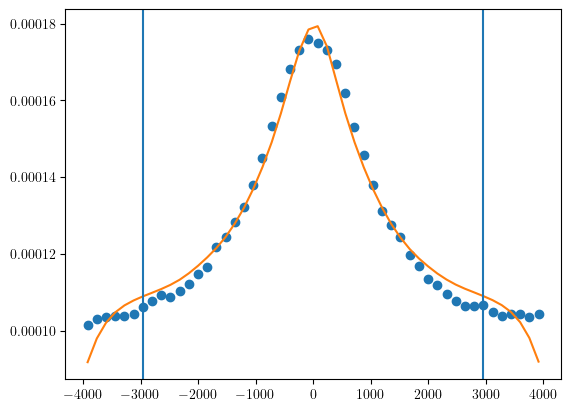

In [335]:
valid_ind = 6
test2 = test[valid_ind:-(valid_ind+1)]
plt.scatter(test_vc, test_hist/np.sum(test_hist*np.diff(test_vc)[0]))
plt.plot(test_vc, test/ np.sum(test*np.diff(test_vc)[0]), c='C1') #/ np.sum(test[10:-10]*np.diff(test_v)[0])
plt.axvline(test_vc[valid_ind])
plt.axvline(test_vc[-(valid_ind+1)])

In [324]:
np.sum(test_hist/np.sum(test_hist*np.diff(test_vc)[0]))

np.float64(0.00625)

In [326]:
np.sum(test2/ np.sum(test2*np.diff(test_v[valid_ind:-valid_ind])[0]))

np.float64(0.009899999999999989)

In [11]:
# better interpolation?

def P_vphys_R_fromhists(v_phys, R_ind, M_ind):
    R = r_cens[R_ind]
    M = Mvirs[M_ind] # * 1e14

    h = cosmo.h
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)

    # r_LOS integration range (now spans negative to positive)
    rlos_vals = rlos_cens  # Assumes rlos_cens goes from -rlos_max to +rlos_max

    # Determine velocity grid range based on v_phys and rlos_vals
    rlos_max = np.abs(rlos_vals).max()
    
    # Calculate vpec range MORE carefully to ensure full coverage
    vpec_min = v_phys.min() - a * H * rlos_max / h
    vpec_max = v_phys.max() - a * H * (-rlos_max) / h
    
    # Increased buffer for better tail coverage
    v_buffer = 2000
    vr_e = np.linspace(vpec_min - v_buffer, vpec_max + v_buffer, 1000+1)
    vr_grid = 0.5*(vr_e[1:]+vr_e[:-1])

    # Shape (n_v, n_r)
    vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 
    
    # Compute P(vlos | R, rlos) for all rlos on vr_grid
    if R_ind <= 10:
        vels = vpeclos
    else:
        vels = vpeclos_ls

    Pvlos_grid = np.array([np.histogram(vels[ind + R_ind*len(rlos_cens) + M_ind*len(r_cens)*len(rlos_cens)], 
                                        bins=vr_e, 
                                        density=True)[0] for ind in range(len(rlos_cens))])
    # shape (n_r, n_v)

    # Apply Gaussian smoothing to each histogram before interpolation
    from scipy.ndimage import gaussian_filter1d
    
    Pvlos_grid_smoothed = np.array([gaussian_filter1d(Pvlos_grid[j], sigma=5.0) 
                                     for j in range(len(rlos_vals))])
    
    # Renormalize after smoothing to maintain probability conservation
    for j in range(len(rlos_vals)):
        integral = np.trapz(Pvlos_grid_smoothed[j], vr_grid)
        if integral > 0:
            Pvlos_grid_smoothed[j] /= integral

    # Use cubic interpolation for smoother behavior in tails
    from scipy.interpolate import interp1d
    
    Pvlos_interp_list = []
    for j in range(len(rlos_vals)):
        # Create interpolator with cubic spline on smoothed data
        interp_func = interp1d(vr_grid, Pvlos_grid_smoothed[j], kind='cubic', 
                               bounds_error=False, fill_value=0.0)
        Pvlos_interp_list.append(interp_func(vpec[:, j]))
    
    Pvlos_interp = np.array(Pvlos_interp_list)  # shape (n_r, n_v)
    Pvlos_interp = Pvlos_interp.T  # shape (n_v, n_r)

    # Weight factor using absolute value of rlos for 3D distance
    r3d = np.sqrt(R**2 + rlos_vals**2)
    weight = 0.014 * (cf_inf(r3d, M, cf_pars) + 1)  
    # shape (n_r,)

    # Multiply and integrate over rlos using Simpson's rule for higher accuracy
    integrand = Pvlos_interp * weight[None, :]  
    from scipy.integrate import simpson
    P_out = simpson(integrand, x=rlos_vals, axis=1)  # shape (n_v,)

    # Normalize by Sigma(R)
    sigma_R = Sigma_inf(R, M, cf_pars)
    P_out /= sigma_R

    # No symmetrization needed since we integrate over full range
    dist = P_out

    return dist / dist.sum() / np.diff(v_phys)[0]

test = P_vphys_R_fromhists(vcens, 10, 0)


/tmp/ipykernel_1524031/2261783008.py:49: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(Pvlos_grid_smoothed[j], vr_grid)


In [255]:
test_ve = np.linspace(-4000, 4000, 51)
test_vc = 0.5*(test_ve[1:]+test_ve[:-1])

v_phys = test_vc #vcens
R_ind = 10
M_ind = 0

R = r_cens[R_ind]
M = Mvirs[M_ind] # * 1e14

h = cosmo.h 
a = 0.83760
redshift=1/a-1
H = h*100*cosmo.Ez(redshift)

rlos_vals = rlos_cens

vpec_data_max = 4000.0

v_buffer = 500
vr_e = np.linspace(-vpec_data_max - v_buffer, vpec_data_max + v_buffer, 50+1)
vr_grid = 0.5*(vr_e[1:]+vr_e[:-1])

vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 

valid_mask = np.zeros((len(v_phys), len(rlos_vals)), dtype=bool)
for j, rlos in enumerate(rlos_vals):
    v_phys_min_valid = -vpec_data_max + a * H * rlos / h
    v_phys_max_valid = vpec_data_max + a * H * rlos / h
    valid_mask[:, j] = (v_phys >= v_phys_min_valid) & (v_phys <= v_phys_max_valid)

if R_ind <= 10:
    vels = vpeclos
else:
    vels = vpeclos_ls

# Get histograms WITHOUT density normalization
# Pvlos_grid = []
# for ind in range(len(rlos_cens)):
#     vel_data = vels[ind + R_ind*len(rlos_cens) + M_ind*len(r_cens)*len(rlos_cens)]
    
#     # Count histogram
#     hist, _ = np.histogram(vel_data, bins=vr_e, density=True)

    
#     Pvlos_grid.append(hist)

# Pvlos_grid = np.array(Pvlos_grid)
Pvlos_grid = np.array([P_vlos_R_rlos(vr_grid, R, rlos, M, gal_MAP) for rlos in rlos_vals])  


from scipy.interpolate import interp1d

Pvlos_interp_list = []
counter = 0

for j in range(len(rlos_vals)):
    interp_func = interp1d(vr_grid, Pvlos_grid[j], kind='cubic', 
                           bounds_error=False, fill_value=0.0)
    interpolated = interp_func(vpec[:, j])
    interpolated[~valid_mask[:, j]] = 0.0
    
    bin_width = np.diff(vpec[:, j])[0]
    cumsum = np.cumsum(interpolated)*bin_width
    
    if cumsum[-1] < 0.97:
        interpolated = interpolated * (1 - cumsum[-1]) 
        counter += 1

    Pvlos_interp_list.append(interpolated)
print(counter)

Pvlos_interp = np.array(Pvlos_interp_list)
Pvlos_interp = Pvlos_interp.T 

r3d = np.sqrt(R**2 + rlos_vals**2)
weight = 0.014 * (cf_inf(r3d, M, cf_pars) + 1)

integrand = Pvlos_interp * weight[None, :]
from scipy.integrate import simpson
P_out = simpson(integrand, x=rlos_vals, axis=1)

sigma_R = Sigma_inf(R, M, h, cf_pars)
P_out /= sigma_R

dv = np.diff(v_phys)[0]

mod_test = P_out #/ np.sum(P_out) / dv

/tmp/ipykernel_1239753/1533926899.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(np.trapz(jd, vr, dx=np.diff(vr)[0], axis=-2), vt, dx=np.diff(vt)[0], axis=-1)
/tmp/ipykernel_1239753/1533926899.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out[i] = np.trapz(integrand, vr)


276


In [21]:
# test optimized fcn
from scipy.integrate import simpson
from scipy.interpolate import interp1d, RectBivariateSpline

def P_vphys_R_vec_optimized(v_phys, R, M, pars):

    M = M * 1e14
    
    h = cosmo.h 
    a = 0.83760
    redshift = 1/a - 1
    H = h * 100 * cosmo.Ez(redshift)
    
    rlos_vals = rlos_cens
    vpec_data_max = 4000.0
    v_buffer = 500
    
    # Create velocity grid (consider reducing resolution if acceptable)
    vr_e = np.linspace(-vpec_data_max - v_buffer, vpec_data_max + v_buffer, 50+1)
    vr_grid = 0.5 * (vr_e[1:] + vr_e[:-1])
    
    # Compute Pvlos grid once
    Pvlos_grid = np.array([P_vlos_R_rlos(vr_grid, R, rlos, M, pars) 
                           for rlos in rlos_vals])
    
    # Use 2D interpolation instead of creating multiple 1D interpolators
    # This is much faster for vectorized evaluation
    Pvlos_interp_func = RectBivariateSpline(
        rlos_vals, vr_grid, Pvlos_grid, kx=3, ky=3
    )
    
    # Vectorized computation of vpec for all combinations
    vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h
    
    # Evaluate interpolation in vectorized manner
    # RectBivariateSpline can handle 2D arrays efficiently
    Pvlos_interp = np.zeros_like(vpec)
    for i, v_p in enumerate(v_phys):
        Pvlos_interp[i, :] = Pvlos_interp_func(rlos_vals, vpec[i, :], grid=False)
    
    # Set out-of-bounds values to zero
    valid_mask = (vpec >= -vpec_data_max) & (vpec <= vpec_data_max)
    Pvlos_interp[~valid_mask] = 0.0
    
    # Vectorized weight computation
    r3d = np.sqrt(R**2 + rlos_vals**2)
    weight = 0.014 * (cf_inf(r3d, M, cf_pars) + 1)
    
    # Vectorized integration
    integrand = Pvlos_interp * weight[None, :]
    P_out = simpson(integrand, x=rlos_vals, axis=1)
    
    # Normalize
    sigma_R = Sigma_inf(R, M, h, cf_pars)
    P_out /= sigma_R
    
    return P_out

In [37]:
%%timeit

P_vlos_R_rlos(test_vc, r_cens[10], rlos_cens_red[0], Mvirs[0], gal_MAP) 

/tmp/ipykernel_1342161/1533926899.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(np.trapz(jd, vr, dx=np.diff(vr)[0], axis=-2), vt, dx=np.diff(vt)[0], axis=-1)
/tmp/ipykernel_1342161/1533926899.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out[i] = np.trapz(integrand, vr)


35.3 ms ± 7.57 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [38]:
len(rlos_cens_red)

1000

In [33]:
test = np.array([P_vlos_R_rlos(test_vc, r_cens[10], rlos, Mvirs[0], gal_MAP) for rlos in rlos_cens_red])  

/tmp/ipykernel_1342161/1533926899.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(np.trapz(jd, vr, dx=np.diff(vr)[0], axis=-2), vt, dx=np.diff(vt)[0], axis=-1)
/tmp/ipykernel_1342161/1533926899.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out[i] = np.trapz(integrand, vr)


In [9]:
test_ve = np.linspace(-4000, 4000, 51)
test_vc = 0.5*(test_ve[1:]+test_ve[:-1])

In [35]:

def P_vphys_R_vec(v_phys, R, M, pars):
    M = M * 1e14

    h = cosmo.h
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)

    # r_LOS integration range
    rlos_max = 80 #60 #100 #np.sqrt(60**2 - R**2)
    rlos_vals_pos = np.geomspace(1e-8, rlos_max, 500)
    rlos_vals_neg = -np.flip(rlos_vals_pos)
    rlos_vals = np.concatenate([rlos_vals_pos, rlos_vals_neg])

    # Shape (n_v, n_r)
    vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 

    # velocity grid for interpolation
    vr_grid = np.linspace(-np.max(vpec), np.max(vpec), 1000) 

    # Compute P(vlos | R, rlos) for all rlos on vr_grid
    Pvlos_grid = np.array([P_vlos_R_rlos(vr_grid, R, rlos, M, pars) for rlos in rlos_vals])  
    # shape (n_r, n_v)

    # Interpolate along vr_grid axis for each rlos
    Pvlos_interp = np.array([
        np.interp(vpec[:, j], vr_grid, Pvlos_grid[j], left=None, right=None)
        for j in range(len(rlos_vals))
    ])  # shape (n_r, n_v)

    # Now shape (n_v, n_r)
    Pvlos_interp = Pvlos_interp.T  

    # Weight factor
    weight = 0.014 * (cf_inf(np.sqrt(R**2 + rlos_vals**2), M, cf_pars) + 1)  
    # shape (n_r,)

    # Multiply and integrate over rlos
    integrand = Pvlos_interp * weight[None, :]  
    P_out = np.trapz(integrand, rlos_vals, axis=1)  # shape (n_v,)

    # Normalize by Sigma(R)
    sigma_R = Sigma_inf(R, M, cf_pars)
    P_out /= sigma_R

    # Symmetrize
    dist = P_out #+ np.flip(P_out)

    return dist / dist.sum() / np.diff(v_phys)[0]

In [36]:
mod_test = P_vphys_R_vec(test_vc, r_cens[10], Mvirs[0]/1e14, gal_MAP)

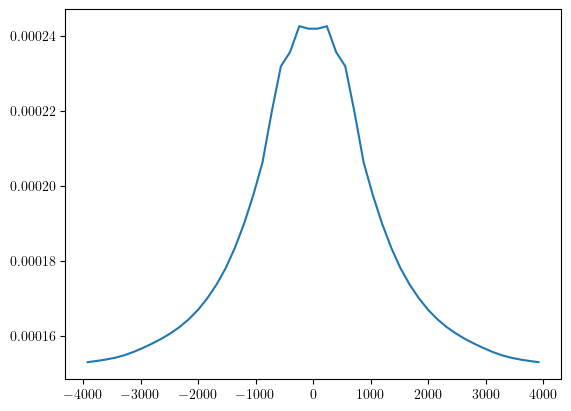

In [37]:
plt.plot(test_vc, mod_test/np.sum(mod_test[9:-9]*np.diff(test_vc)[0]))

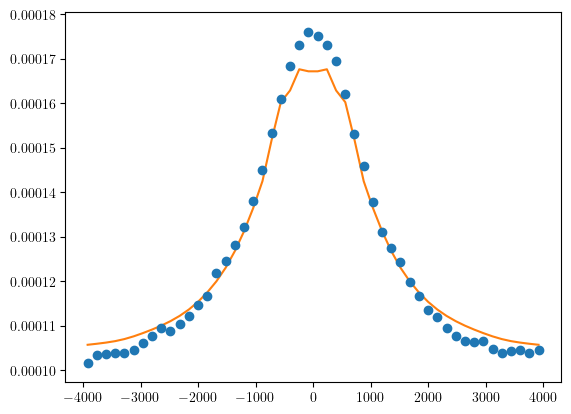

In [38]:
#valid_ind = 3
hist, _ = np.histogram(vphyslos[10], bins=50, range=[-4000, 4000], density=False)
plt.errorbar(test_vc, hist/np.sum(hist*np.diff(test_vc)[0]) , np.sqrt(hist)/np.sum(hist*np.diff(test_vc)[0]), fmt='o')
plt.plot(test_vc, mod_test/np.sum(mod_test*np.diff(test_vc)[0]) , c='C1') # - (test[24] - hist[0][24])
#plt.xlim((-2500, 2500)) 

(3440.0, -3440.0)

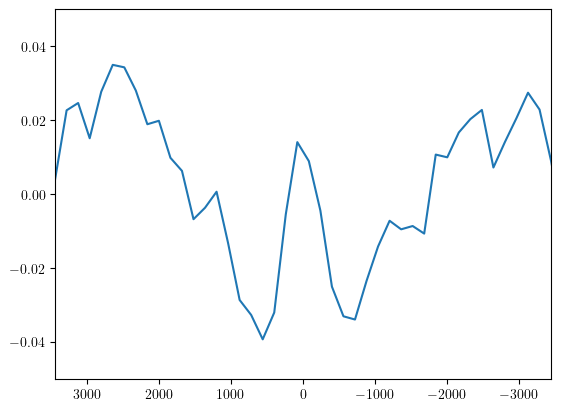

In [300]:
plt.plot(test_vc, (mod_test/np.sum(mod_test[valid_ind:-valid_ind]*np.diff(test_vc)[0]) - hist/np.sum(hist[valid_ind:-valid_ind]*np.diff(test_vc)[0]))/(hist/np.sum(hist[valid_ind:-valid_ind]*np.diff(test_vc)[0])) )
plt.ylim((-0.05, 0.05))
plt.xlim((-test_vc[valid_ind], test_vc[valid_ind])) 

In [303]:
-test_vc[valid_ind]

np.float64(2480.0)

(-2500.0, 2500.0)

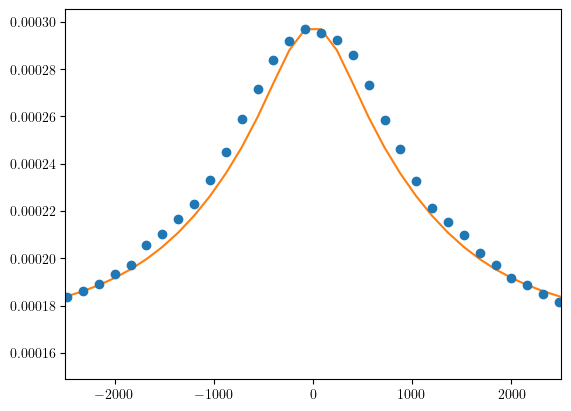

In [237]:
hist, _ = np.histogram(vphyslos[10], bins=50, range=[-4000, 4000], density=False)
plt.errorbar(test_vc, hist/np.sum(hist[12:-12]*np.diff(test_vc)[0]) , np.sqrt(hist)/np.sum(hist[12:-12]*np.diff(test_vc)[0]), fmt='o')
plt.plot(test_vc, mod_test/np.sum(mod_test[12:-12]*np.diff(test_vc)[0])  - ( (mod_test/np.sum(mod_test[12:-12]*np.diff(test_vc)[0]))[24] - (hist/np.sum(hist[12:-12]*np.diff(test_vc)[0]))[24] ) , c='C1') # - (test[24] - hist[0][24])
plt.xlim((-2500, 2500)) 

In [13]:
vcens

array([-1960., -1880., -1800., -1720., -1640., -1560., -1480., -1400.,
       -1320., -1240., -1160., -1080., -1000.,  -920.,  -840.,  -760.,
        -680.,  -600.,  -520.,  -440.,  -360.,  -280.,  -200.,  -120.,
         -40.,    40.,   120.,   200.,   280.,   360.,   440.,   520.,
         600.,   680.,   760.,   840.,   920.,  1000.,  1080.,  1160.,
        1240.,  1320.,  1400.,  1480.,  1560.,  1640.,  1720.,  1800.,
        1880.,  1960.])

(-2000.0, 2000.0)

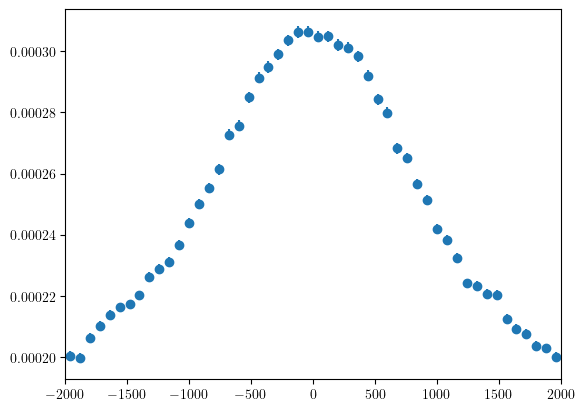

In [14]:
#veed = np.linspace(-2000, 2000, 50+1)
#vecens = 0.5*(veed[1:]+veed[:-1])
#test = P_vphys_R_fromhists(vecens, 10, 0)
#dv = np.diff(vcens)[0]
hist, _ = np.histogram(vphyslos[10], bins=50, range=[-2000, 2000], density=False)
plt.errorbar(vcens, hist/np.sum(hist*np.diff(vcens)[0]) , np.sqrt(hist)/np.sum(hist*np.diff(vcens)[0]), fmt='o')
plt.plot(vcens, test/np.sum(test*np.diff(vcens)[0])  , c='C1') # - (test[24] - hist[0][24])
plt.xlim((-2000, 2000)) 

(-2500.0, 2500.0)

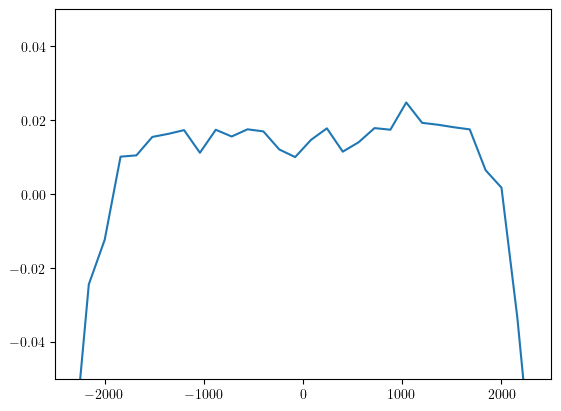

In [169]:
plt.plot(test_vc, (test/np.sum(test[9:-9]*np.diff(test_vc)[0]) - hist/np.sum(hist[9:-9]*np.diff(test_vc)[0]))/(hist/np.sum(hist[9:-9]*np.diff(test_vc)[0])) )
plt.ylim((-0.05, 0.05))
plt.xlim((-2500, 2500)) 

In [ ]:
# NOTE: rescale 'snipped' histograms by 1 - area under curve up until cutoff, or smthng like that?

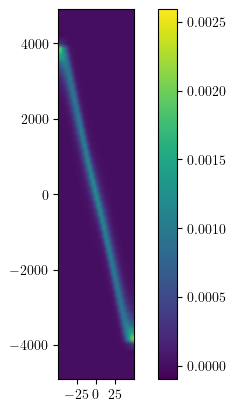

In [139]:
plt.imshow(Pvlos_interp, aspect=50/1000, extent=[rlos_cens[0], rlos_cens[-1], test_vc[0], test_vc[-1]])
plt.colorbar()

In [191]:
snipped = (Pvlos_interp[0, :] > 0.1) | (Pvlos_interp[-1, :] > 0)  
#np.sum(snipped) / Pvlos_interp.shape[1] 
len(rlos_cens[~snipped])

338

0.9998370282885497
1.0001940785943944


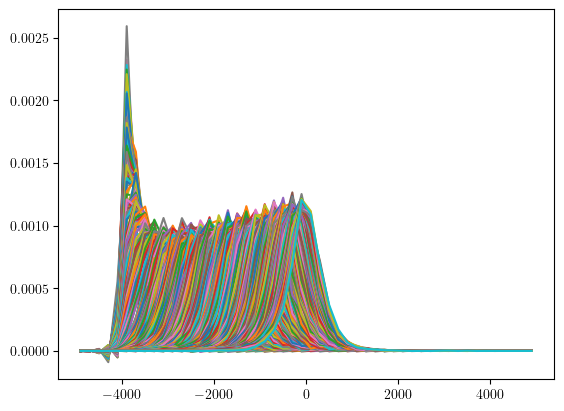

In [140]:
for i in range(500):
    test_dist = Pvlos_interp[:, i]
    if np.cumsum(test_dist)[-1]*dv < 0.999:
        test_dist = test_dist*(1-np.cumsum(test_dist)[-1]*dv)
    plt.plot(test_vc, test_dist)
    if i == 0 or i == 499:
        print(np.sum(test_dist)*dv)
    #plt.plot(test_vc, Pvlos_interp[:, -i])

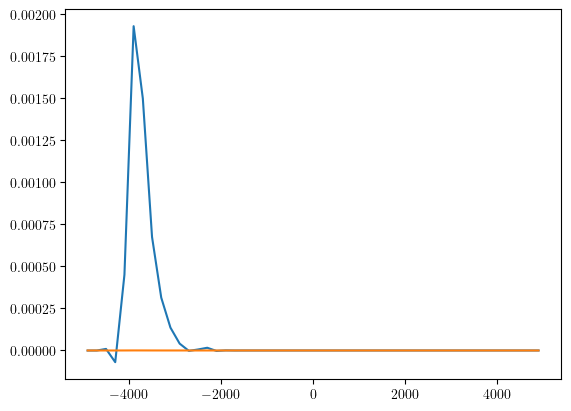

In [141]:
plt.plot(test_vc, Pvlos_interp[:, 0])
plt.plot(test_vc, Pvlos_interp[:, 0]*(1-np.cumsum(Pvlos_interp[:, 0])[-1]*dv))

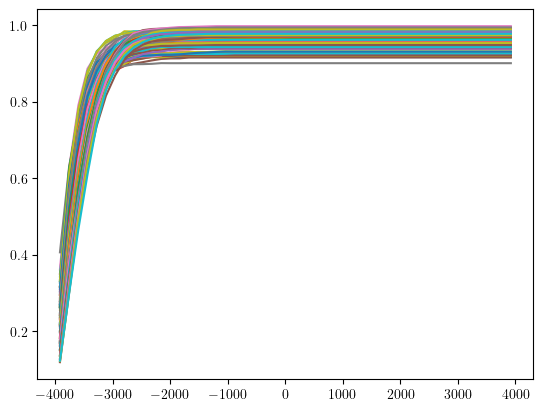

In [52]:
for i in range(100):    
    plt.plot(test_vc, np.cumsum(Pvlos_interp[:, i])*dv)


/tmp/ipykernel_1239753/2827157747.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"Integral of dist1: {np.trapz(pdf1, dx=dx):.4f}")
/tmp/ipykernel_1239753/2827157747.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"Integral of dist2 (raw): {np.trapz(pdf2, dx=dx):.4f}")
/tmp/ipykernel_1239753/2827157747.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"Integral of dist2 (renormalized): {np.trapz(pdf2_renormalized, dx=dx):.4f}")


Integral of dist1: 0.9991
Integral of dist2 (raw): 0.9087
Integral of dist2 (renormalized): 0.9999


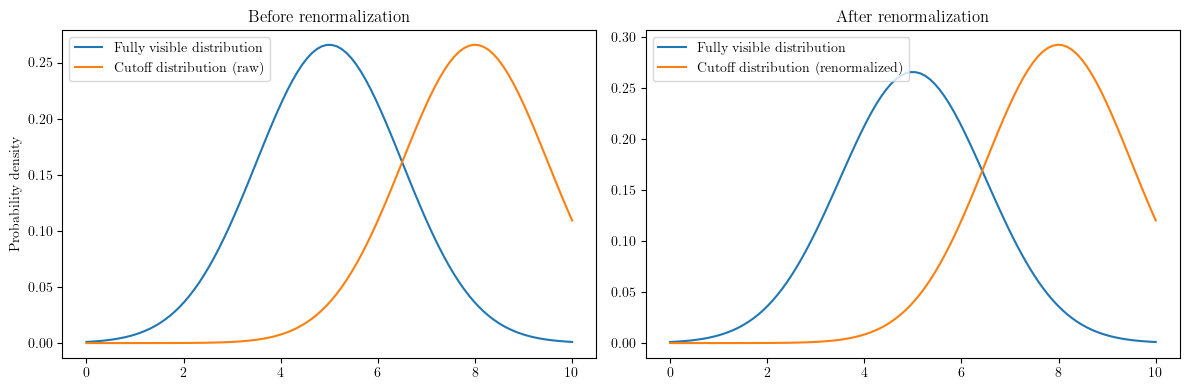

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Example: Create two distributions
x_range = np.linspace(0, 10, 100)

# Distribution 1: fully visible (mean=5, std=1.5)
dist1 = stats.norm(loc=5, scale=1.5)
pdf1 = dist1.pdf(x_range)

# Distribution 2: partially cutoff (mean=8, std=1.5)
# Much of this distribution falls beyond x=10
dist2 = stats.norm(loc=8, scale=1.5)
pdf2 = dist2.pdf(x_range)

# Calculate the fraction of dist2 that's actually in the visible range
# This is the CDF evaluated at the boundaries
fraction_visible = dist2.cdf(x_range[-1]) - dist2.cdf(x_range[0])

# Renormalize the cutoff distribution
pdf2_renormalized = pdf2 / fraction_visible

# Verify normalization by integrating
dx = x_range[1] - x_range[0]
print(f"Integral of dist1: {np.trapz(pdf1, dx=dx):.4f}")
print(f"Integral of dist2 (raw): {np.trapz(pdf2, dx=dx):.4f}")
print(f"Integral of dist2 (renormalized): {np.trapz(pdf2_renormalized, dx=dx):.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_range, pdf1, label='Fully visible distribution')
axes[0].plot(x_range, pdf2, label='Cutoff distribution (raw)')
axes[0].set_title('Before renormalization')
axes[0].legend()
axes[0].set_ylabel('Probability density')

axes[1].plot(x_range, pdf1, label='Fully visible distribution')
axes[1].plot(x_range, pdf2_renormalized, label='Cutoff distribution (renormalized)')
axes[1].set_title('After renormalization')
axes[1].legend()

plt.tight_layout()
plt.show() 

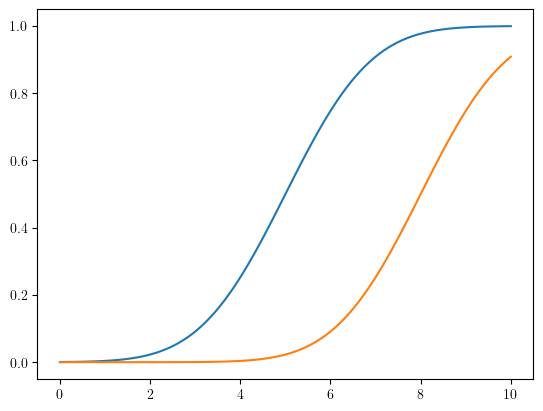

In [43]:
plt.plot(x_range, dist1.cdf(x_range))
plt.plot(x_range, dist2.cdf(x_range))

In [25]:
np.sum(Pvlos_interp[:, 0])*dv/np.sum(Pvlos_interp[:, 0]*dv) #incomplete dist

np.float64(1.0000000000000002)

In [23]:
np.sum(Pvlos_interp[:, 500])*dv #complete dist

np.float64(1.0000835427761254)

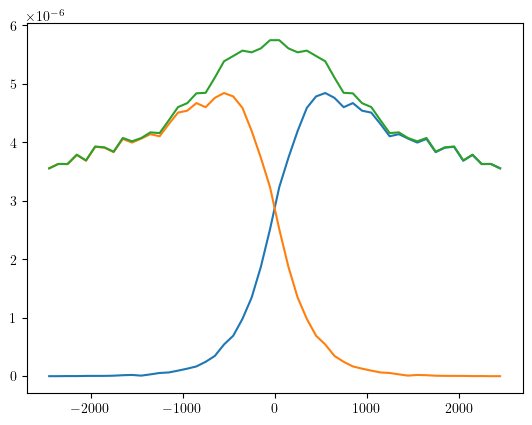

In [110]:
plt.plot(vcens, np.mean(integrand, axis=1))
plt.plot(vcens, np.flip(np.mean(integrand, axis=1)))
dist_test = np.zeros(50)
dist_test[25:] = np.mean(integrand, axis=1)[25:]
dist_test[:25] =  np.flip(np.mean(integrand, axis=1)[25:])
plt.plot(vcens, np.mean(integrand, axis=1)+np.flip(np.mean(integrand, axis=1))) 

In [198]:
vpec.T.shape

(1000, 50)

Text(0.5, 0, '$r_{\\rm LOS}$')

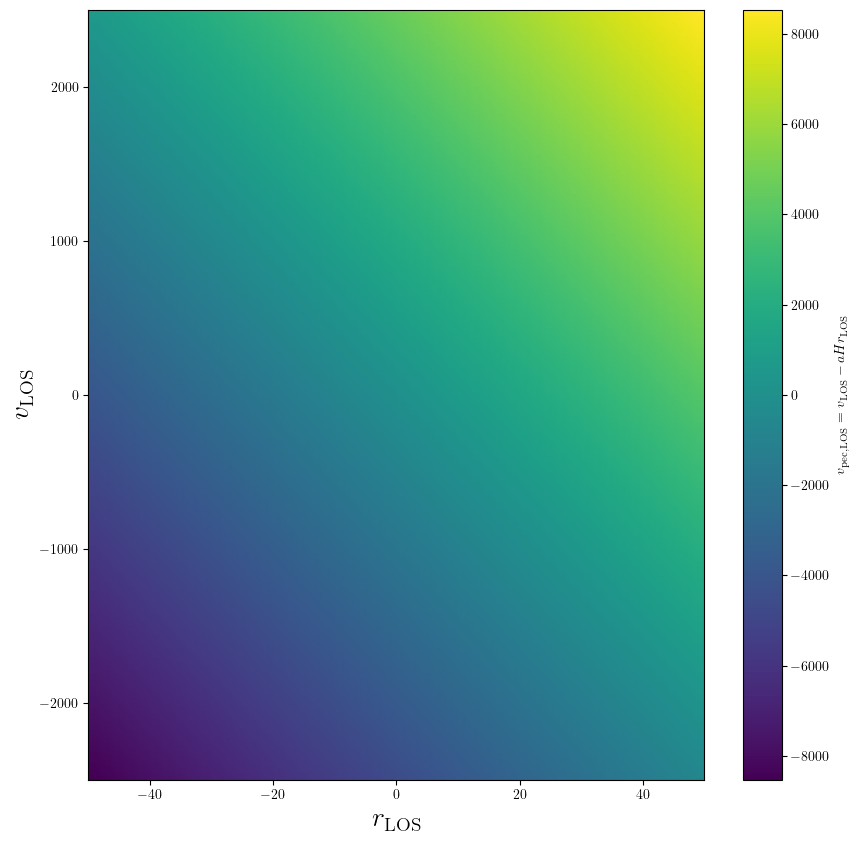

In [201]:
fig, ax = plt.subplots(figsize=(10, 10))

im = ax.imshow(vpec.T, extent=[rlos_edges[0], rlos_edges[-1], vedges[0], vedges[-1]], aspect=25/1000)
#ax.set_xticks(rlos_cens)
#ax.set_yticks(vcens)
plt.colorbar(im, label=r'$v_{\rm pec, LOS} = v_{\rm LOS} - aHr_{\rm LOS}$')
#X, Y = np.meshgrid(rlos_edges, vedges)
#plt.contour(X, Y, Z=vpec, levels=4000)
plt.ylabel(r'$v_{\rm LOS}$', fontsize=20)
plt.xlabel(r'$r_{\rm LOS}$', fontsize=20)

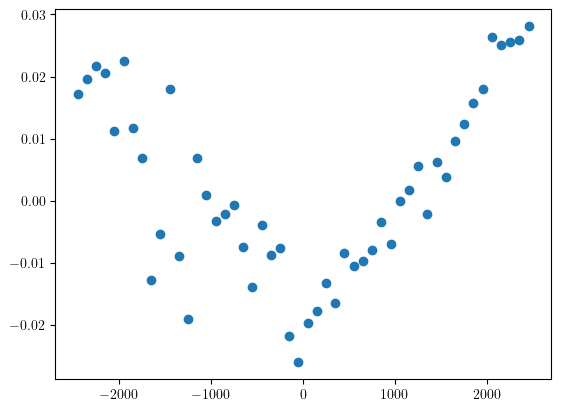

In [141]:
plt.scatter(vcens, (test-hist[0])/hist[0])

In [235]:
np.mean(np.abs((test-hist[0])/hist[0]))

np.float64(0.007437434671787072)

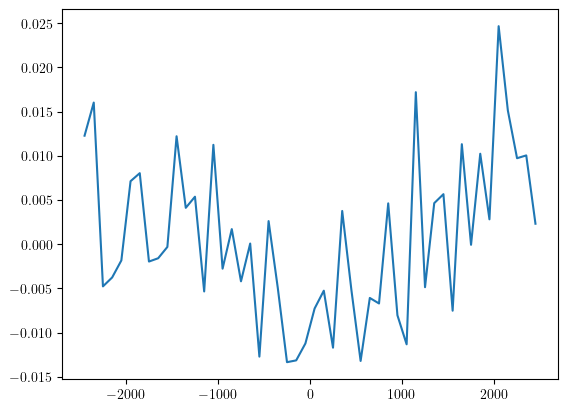

In [236]:
plt.plot(vcens, (test-hist[0])/hist[0])

In [9]:
from tqdm import tqdm


100%|██████████| 11/11 [00:42<00:00,  3.87s/it]


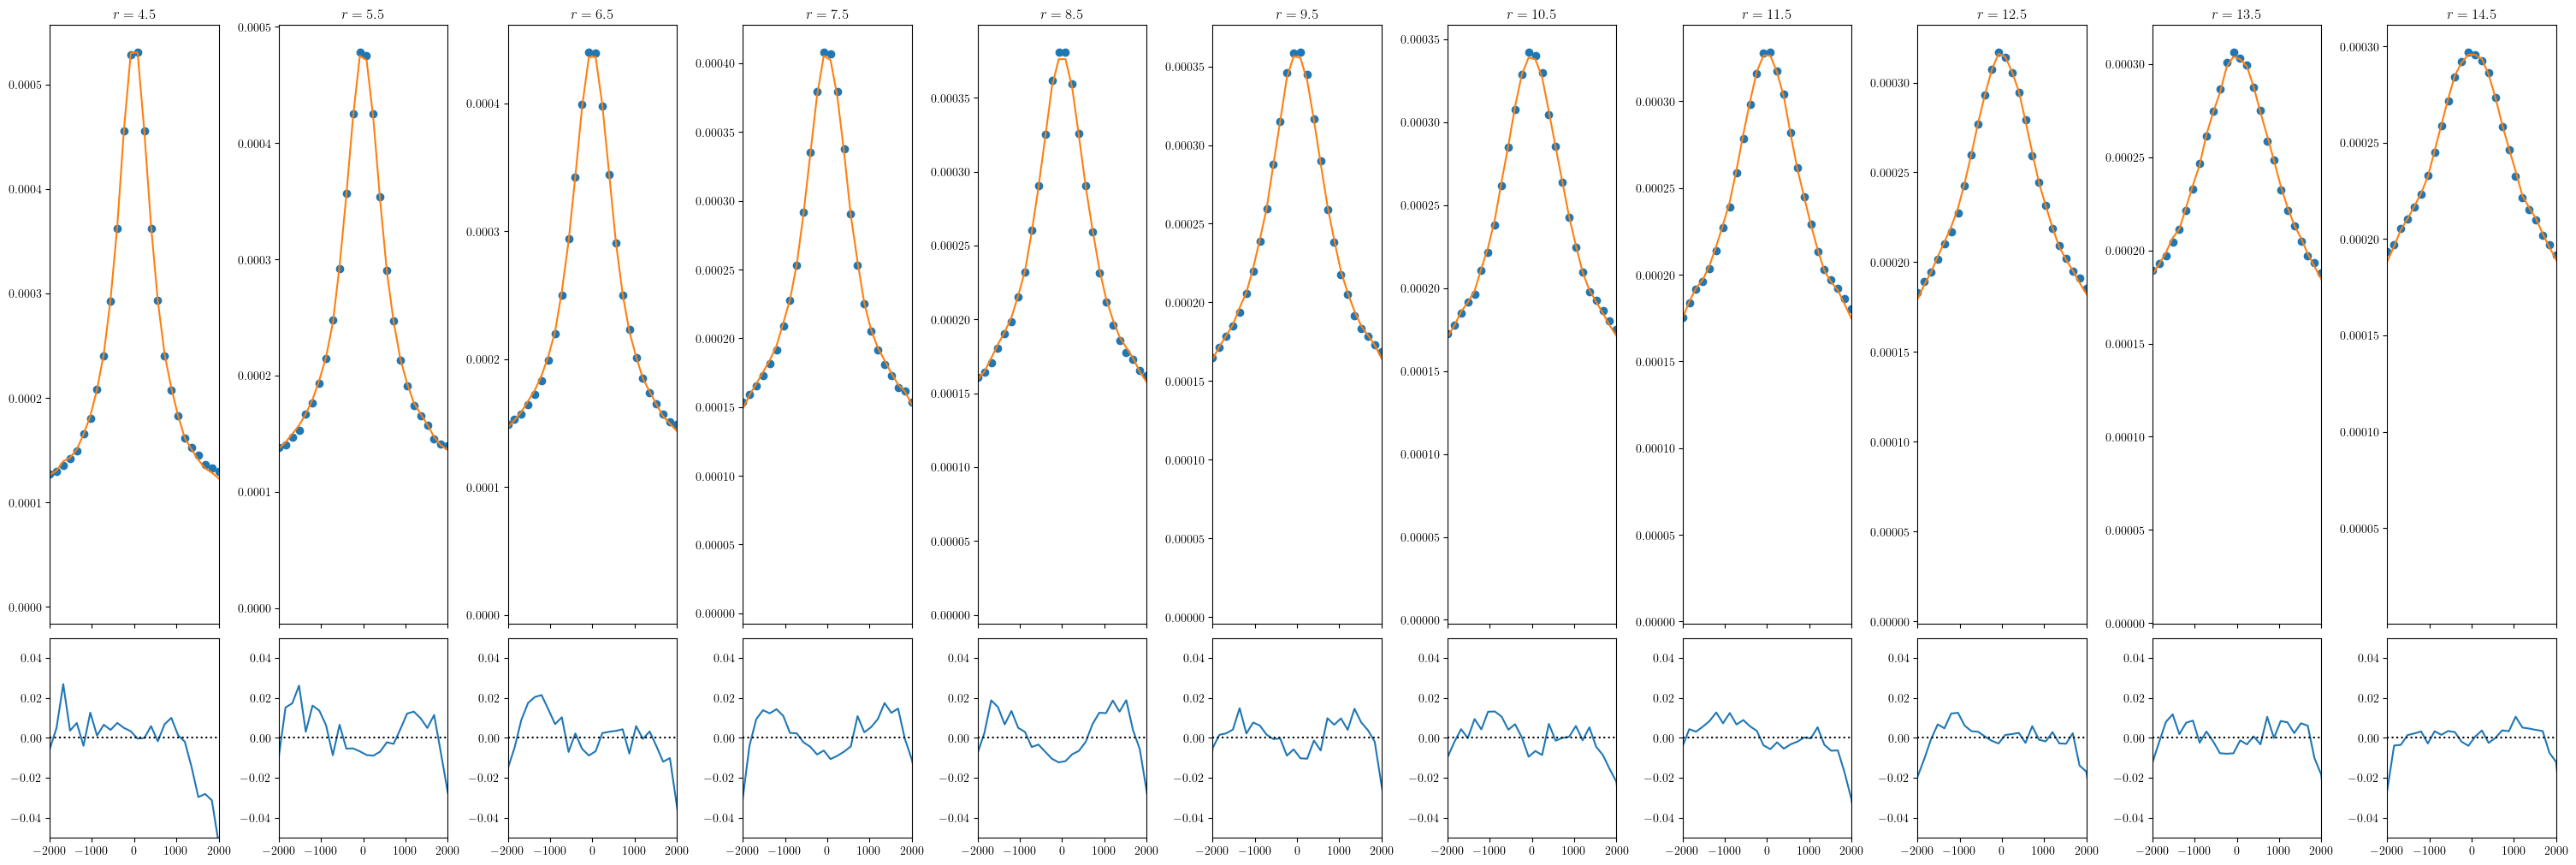

In [ ]:
fig, ax = plt.subplots(2, len(r_cens[:11]), figsize=(30, 10), sharex=True, layout='constrained', gridspec_kw={'height_ratios': [3, 1]})#
k = 0
for i in tqdm(range(len(r_cens[:11]))):
    valid_ind = 3
    dv = np.diff(test_vc)[0]
    test = P_vphys_R_fromhists(test_vc, i, 0)
    test = test / np.sum(test[valid_ind:-valid_ind]*dv)
    #test2 = P_vphys_R_vec(test_vc, r_cens[i], M=Mvirs[0]/1e14, pars=gal_MAP)
    ax[0, i].plot(test_vc, test, c='C1')
    #ax[0, i].plot(test_vc, test2, c='C2')

    index = i #+ len(r_cens)*k
    
    hist, _ = np.histogram(vphyslos[index], bins=bin_num, range=[-4000, 4000], density=False)
    hist = hist/ np.sum(hist[valid_ind:-valid_ind]*dv)

    ax[0, i].scatter(test_vc, hist, c='C0')
    
    #hist = ax[0, i].hist(vphyslos[i], bins=50, range=[-2000, 2000], histtype='step', density=True, color='C1')
    ax[0, i].margins(x=0)
    ax[0, i].set_title(f'$r={r_cens[i]}$')
    #ax[0, i].set_ylim((0, 2*0.0005))

    ax[1, i].plot(test_vc, (test-hist)/hist) 
    #ax[1, i].plot(test_vc, (test2-hist)/hist, c='C2')
    ax[1, i].axhline(0, c='k', ls=':')
    ax[1, i].set_ylim((-0.05, 0.05))
    ax[1, i].margins(x=0)
    ax[0, i].set_xlim((-2000, 2000))
    ax[1, i].set_xlim((-2000, 2000))


  0%|          | 0/26 [00:00<?, ?it/s]/tmp/ipykernel_1342161/1533926899.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(np.trapz(jd, vr, dx=np.diff(vr)[0], axis=-2), vt, dx=np.diff(vt)[0], axis=-1)
/tmp/ipykernel_1342161/1533926899.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out[i] = np.trapz(integrand, vr)
100%|██████████| 26/26 [02:35<00:00,  5.97s/it]


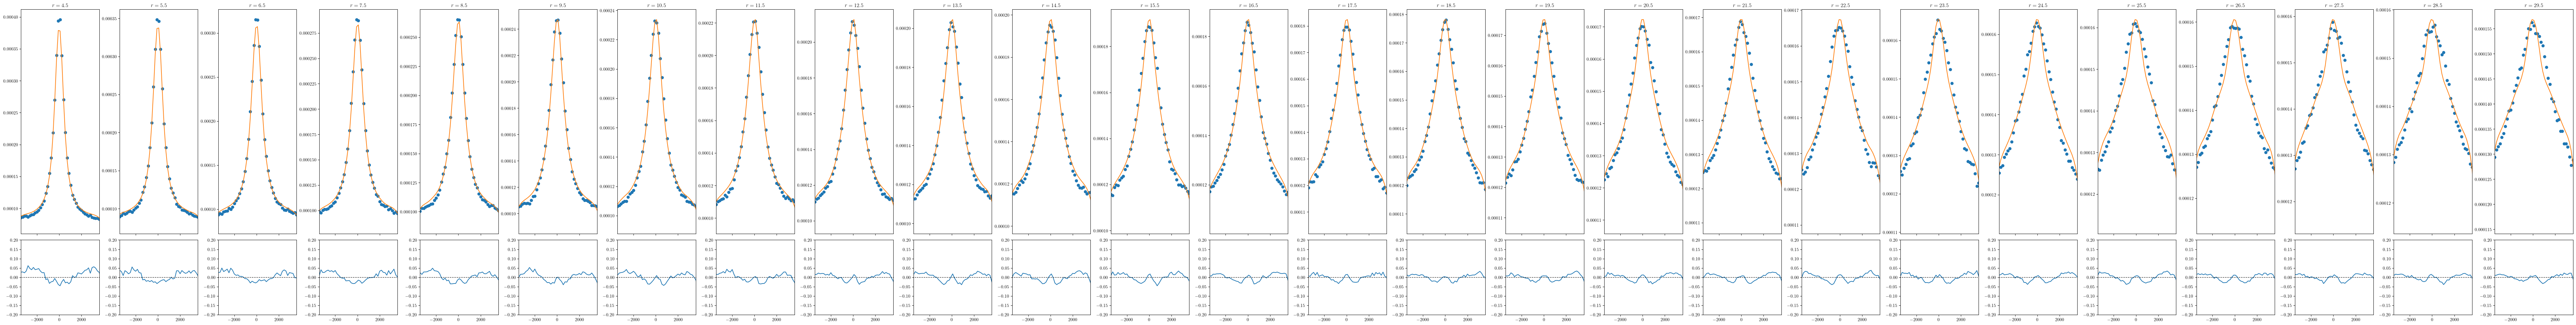

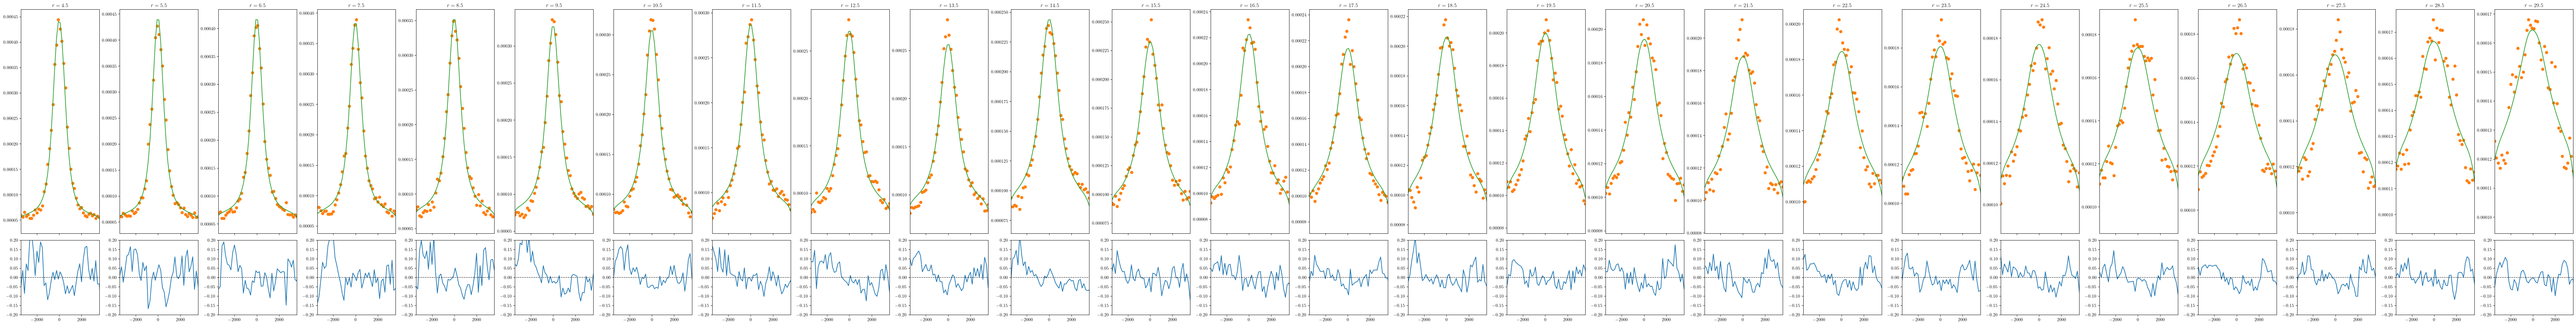

In [42]:
path = '/spiff/cosweeney/simulations/MDPL2/data/model_tests'
mass_inds = [0, 5]
PDs = np.zeros((2, 50))

test_ve = np.linspace(-4000, 4000, 51)
test_vc = 0.5*(test_ve[1:]+test_ve[:-1])

for k in range(len(mass_inds)):
    fig, ax = plt.subplots(2, len(r_cens), figsize=(80, 10), sharex=True, layout='constrained', gridspec_kw={'height_ratios': [3, 1]})#

    for i in tqdm(range(len(r_cens))):
        valid_ind = 3
        dv = np.diff(test_vc)[0]
        test = P_vphys_R_vec(test_vc, r_cens[i], Mvirs[mass_inds[k]]/1e14, gal_MAP)
        np.save(path+f'Pvlos_R_M_{str(mass_inds[k])}', test)
        test = test / np.sum(test[valid_ind:-valid_ind]*dv)
        #test2 = P_vphys_R_vec(test_vc, r_cens[i], M=Mvirs[0]/1e14, pars=gal_MAP)
        ax[0, i].plot(test_vc, test, c=f'C{str(k+1)}')
        #ax[0, i].plot(test_vc, test2, c='C2')

        index = i + len(r_cens)*mass_inds[k]
        if i <= 10:
            veldata = vphyslos[index]
        else:
            veldata = vphyslos_ls[index]
        
        hist, _ = np.histogram(veldata, bins=bin_num, range=[-4000, 4000], density=False)
        hist = hist/ np.sum(hist[valid_ind:-valid_ind]*dv)

        ax[0, i].scatter(test_vc, hist, c=f'C{str(k)}')
        
        #hist = ax[0, i].hist(vphyslos[i], bins=50, range=[-2500, 2500], histtype='step', density=True, color='C1')
        ax[0, i].margins(x=0)
        ax[0, i].set_title(f'$r={r_cens[i]}$')
        #ax[0, i].set_ylim((0, 2*0.0005))

        ax[1, i].plot(test_vc, (test-hist)/hist) 
        PDs[k, :] = (test-hist)/hist
        #ax[1, i].plot(test_vc, (test2-hist)/hist, c='C2')
        ax[1, i].axhline(0, c='k', ls=':')
        ax[1, i].set_ylim((-0.2, 0.2))
        ax[1, i].margins(x=0)
        ax[0, i].set_xlim((test_vc[valid_ind], test_vc[-valid_ind]))
        ax[1, i].set_xlim((test_vc[valid_ind], test_vc[-valid_ind]))
        #print(np.mean((test-hist)/hist), np.mean(np.abs((test-hist)/hist)))


/tmp/ipykernel_1342161/1533926899.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(np.trapz(jd, vr, dx=np.diff(vr)[0], axis=-2), vt, dx=np.diff(vt)[0], axis=-1)
/tmp/ipykernel_1342161/1533926899.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out[i] = np.trapz(integrand, vr)


(-2500.0, 2500.0)

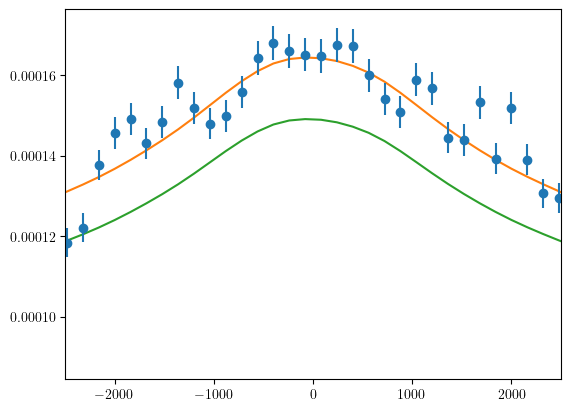

In [59]:
counts, _ = np.histogram(veldata, bins=bin_num, range=[-4000, 4000], density=False)
errs = np.sqrt(counts )/ np.sum(counts[valid_ind:-valid_ind]*dv)

test2 = P_vphys_R_vec(test_vc, r_cens[i], Mvirs[mass_inds[k]]/1e14, gal_MAP)
test2 = test2/np.sum(test2)/np.diff(test_vc)[0]

plt.plot(test_vc, test, c='C1')
plt.plot(test_vc, test2, c='C2')
plt.errorbar(test_vc, hist, errs, fmt='o', c='C0')
plt.xlim((-2500, 2500))

(-2500.0, 2500.0)

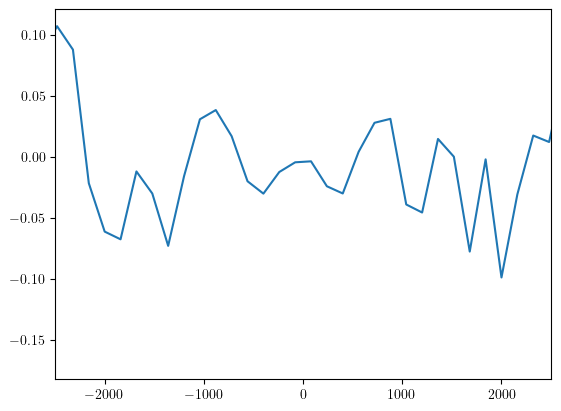

In [55]:
plt.plot(test_vc, (test-hist)/hist) 
#plt.plot(test_vc, (test-hist)/errs) 
plt.xlim((-2500, 2500))

In [56]:
# rescale by conversion factor for DESI estimates

# DESI BGS Estimation
from colossus.cosmology import cosmology

C = cosmology.setCosmology('planck13')
#C = cosmology.Cosmology

Area_deg = 1e4 #deg^2
Area_sr = Area_deg / (180.0/np.pi)**2 

z_1 = 0.1
z_2 = 0.4
delta_z = z_2 - z_1

d_1 = C.comovingDistance(z_min=0.0, z_max=z_1)
d_2 = C.comovingDistance(z_min=0.0, z_max=z_2)

V_DESI = ( Area_sr / 3 ) * ( d_2**3 - d_1**3) # h^-3 Mpc^3

V_MDPL2 = 1000**3 # h^-3 Mpc^3
#n_MDPL2 = 0.014 / cosmo.h**3 # num of galaxies in box / V_MDPL2 in Mpc^-3 
n_MDPL2 = 0.014 # num of galaxies in box / V_MDPL2 in h^3 Mpc^-3 

n_BGS = 1e-3 # h^3 Mpc^-3

N_MDPL2 = np.sum(LOS_hists) 
N_est = N_MDPL2 * V_DESI * n_BGS / V_MDPL2 / n_MDPL2 

conv_BGS = V_DESI * n_BGS / V_MDPL2 / n_MDPL2 


BGS_hists = LOS_hists*conv_BGS

# DESI LRG Estimation

z_1 = 0.4
z_2 = 0.8
delta_z = z_2 - z_1

d_1 = C.comovingDistance(z_min=0.0, z_max=z_1)
d_2 = C.comovingDistance(z_min=0.0, z_max=z_2)

V_DESI = ( Area_sr / 3 ) * ( d_2**3 - d_1**3) # h^-3 Mpc^3

n_LRG = 4.5e-4 # h^3 Mpc^-3 

N_MDPL2 = np.sum(LOS_hists[:, :, :]) 
N_est = N_MDPL2 * V_DESI * n_LRG / V_MDPL2 / n_MDPL2 

conv_LRG = V_DESI * n_LRG / V_MDPL2 / n_MDPL2 

LRG_hists = LOS_hists*conv_LRG

In [66]:
r_cens 

array([ 4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5, 11.5, 12.5, 13.5, 14.5,
       15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5, 22.5, 23.5, 24.5, 25.5,
       26.5, 27.5, 28.5, 29.5])

In [76]:
vxs[10]

np.float64(-3463.0872483221474)

4.5 0.98642004


/tmp/ipykernel_1342161/1533926899.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(np.trapz(jd, vr, dx=np.diff(vr)[0], axis=-2), vt, dx=np.diff(vt)[0], axis=-1)
/tmp/ipykernel_1342161/1533926899.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out[i] = np.trapz(integrand, vr)


14.5 0.98642004
29.5 0.98642004
(np.float64(0.0), np.float64(4532.625853274247))
4.5 8.9311
14.5 8.9311
29.5 8.9311
(np.float64(0.0), np.float64(100.83894842644277))


Text(0.5, 0.98, '$P(v_{\\rm LOS}|R, M)$')

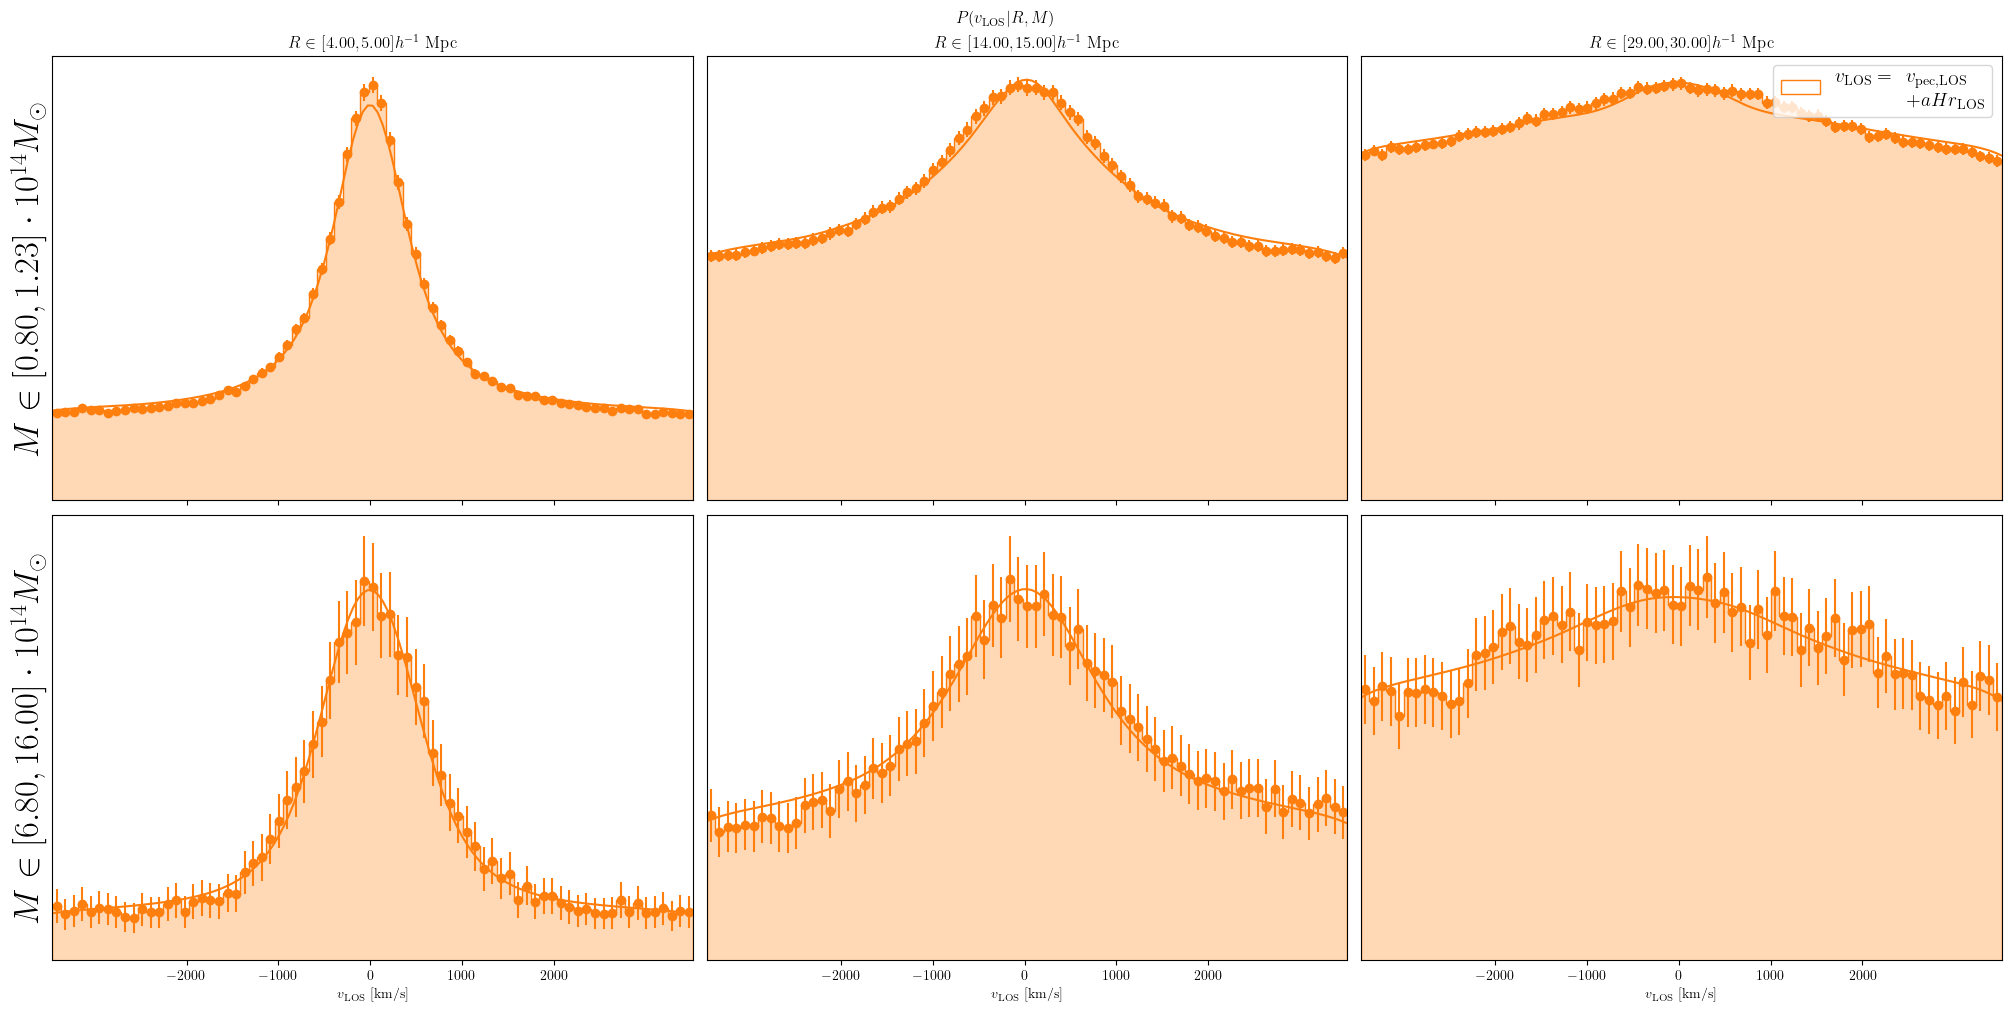

In [208]:
ls_edges = np.linspace(30, 51, 51-30+1)
ls_cens = (ls_edges[1:]+ls_edges[:-1])/2.0

M_select_indices = [0, 5]
M_select_edges = [mbins[i:i+2] for i in M_select_indices] 
M_select_cens = [Mvirs[i] for i in M_select_indices] 

# bins for plots
ls_select_indices = [0, 10, 20]
ls_select_edges = [ls_edges[i:i+2] for i in ls_select_indices] #[edges[2:4], edges[7:9], edges[20:22]]
ls_select_cens = [ls_cens[i] for i in ls_select_indices] #[cens[2], cens[7], cens[20]]

# radial bins
edges = np.linspace(4, 30, 26+1)
cens = (edges[1:]+edges[:-1])/2.0

# bins for plots
select_indices = [0, 10, 25]
select_edges = [edges[i:i+2] for i in select_indices] #[edges[2:4], edges[7:9], edges[20:22]]
select_cens = [cens[i] for i in select_indices] #[cens[2], cens[7], cens[20]]


fig, ax = plt.subplots(2, 3, figsize=(20, 10), layout='constrained', sharex=True)

a = 0.83760
H = 74.71913613009617
h = 0.6777 # damn you, little h!

k = 0
i = 0
for k in range(len(M_select_cens)):
    for i in range(len(select_cens)):
        if i < 2:
            valid_ind = 3
            valid_ind_smooth = 10
            vxs = np.linspace(-4_000, 4_000, 150) 
            R = cens[select_indices[i]] #np.sqrt(np.mean(Rdata[nbins*select_indices[i]+select_indices[j]]**2))

            index2 = select_indices[i] + M_select_indices[k]*len(cens)

            nphys, bins = np.histogram(vphyslos[index2], bins=75, range=(vxs[valid_ind_smooth], vxs[-valid_ind_smooth]), density = False) #range=(test_vc[valid_ind], test_vc[-valid_ind])
            nphys = nphys*conv_BGS #/np.sum(nphys[valid_ind:-valid_ind]*dv) #*conv_BGS

            cent = (bins[:-1] + bins[1:])/2. 
            dv = np.diff(bins)[0]

            print(cens[select_indices[i]], Mvirs[M_select_indices[k]]/1e14)
            #model = P_vlos_R_romb(vxs, cens[select_indices[i]], Mvirs[M_select_indices[k]])
            model_dist = P_vphys_R_vec(vxs, cens[select_indices[i]], Mvirs[M_select_indices[k]]/1e14, pars=gal_MAP)
            model_dist = model_dist / np.sum(model_dist[valid_ind_smooth:-valid_ind_smooth]*np.diff(vxs)[0])
            model_phys = np.sum(nphys)*model_dist*np.diff(cent)[0] 

            #ax[k, i].hist(cent, bins=bins, weights=n, color="C0", histtype='stepfilled', alpha=0.3, label=r'$v_{\rm pec, LOS}$') 
            #ax[k, i].hist(cent, bins=bins, weights=n, color="C0", histtype='step') 

            ax[k, i].hist(cent, bins=bins, weights=nphys, color="C1", histtype='stepfilled', alpha=0.3, label=r"$\begin{array}{rl} v_{\rm LOS} = &v_{\rm pec, LOS} \\ &+ aHr_{\rm LOS} \end{array}$")
            ax[k, i].hist(cent, bins=bins, weights=nphys, color="C1", histtype='step')
            ax[k, i].errorbar(cent, nphys, np.sqrt(nphys), fmt='o', c='C1')

            #ax[k, i].plot(vxs, model, color="C0")
            ax[k, i].plot(vxs, model_phys, color="C1")
            #ax[k, i].plot(vcens,  np.sum(nphys)*P_vphys_R_int(Mvirs[M_select_indices[k]]/1e14)[:, select_indices[i]]*np.diff(cent)[0], color='C0', ls='--')
            ax[1, i].set_xlabel(r'$v_{\rm LOS}$ [km/s]')
            ax[k, 0].set_ylabel(r'$M \in [{:.2f}, {:.2f}] \cdot 10^{{14}} M_\odot$'.format(M_select_edges[k][0]/1e14, M_select_edges[k][1]/1e14), fontsize=25)
            ax[k, i].set_yticks([])
            ax[1, i].set_xticks([-2000, -1000, 0, 1000, 2000])
            ax[1, i].set_xlim((vxs[valid_ind_smooth], vxs[-valid_ind_smooth]))
            ax[0, i].set_xlim((vxs[valid_ind_smooth], vxs[-valid_ind_smooth]))
            ax[0, i].set_title(r'$R \in [{:.2f}, {:.2f}] h^{{-1}}$ Mpc'.format(select_edges[i][0], select_edges[i][1]))
            ax[0, i].margins(x=0)

        if i == 2:
            index2 = select_indices[i] + M_select_indices[k]*len(cens) #ls_select_indices[i] + M_select_indices[k]*len(ls_cens)
            nphys, bins = np.histogram(vphyslos_ls[index2], bins=75, range=(vxs[valid_ind_smooth], vxs[-valid_ind_smooth]), density = False) #range=(test_vc[valid_ind], test_vc[-valid_ind])
            nphys = nphys*conv_BGS #/np.sum(nphys[valid_ind:-valid_ind]*dv) #*conv_BGS
            cent = (bins[:-1] + bins[1:])/2. 


            print(cens[select_indices[i]], Mvirs[M_select_indices[k]]/1e14)
            #model = P_vlos_R_romb(vxs, cens[select_indices[i]], Mvirs[M_select_indices[k]])
            model_dist = P_vphys_R_vec(vxs, cens[select_indices[i]], Mvirs[M_select_indices[k]]/1e14, pars=gal_MAP)
            model_dist = model_dist / np.sum(model_dist[valid_ind_smooth:-valid_ind_smooth]*np.diff(vxs)[0])
            model_phys = np.sum(nphys)*model_dist*np.diff(cent)[0] 


            #ax[k, i].hist(cent, bins=bins, weights=n, color="C0", histtype='stepfilled', alpha=0.3) 
            #ax[k, i].hist(cent, bins=bins, weights=n, color="C0", histtype='step', label=r'$v_{\rm pec, LOS}$') 

            ax[k, i].hist(cent, bins=bins, weights=nphys, color="C1", histtype='stepfilled', alpha=0.3)
            ax[k, i].errorbar(cent, nphys, np.sqrt(nphys), fmt='o', c='C1')
            ax[k, i].hist(cent, bins=bins, weights=nphys, color="C1", histtype='step', label=r"$\begin{array}{rl} v_{\rm LOS} = &v_{\rm pec, LOS} \\ &+ aHr_{\rm LOS} \end{array}$")

            #ax[k, i].plot(vxs, model, color="C0") 
            ax[k, i].plot(vxs, model_phys, color="C1")
            #ax[k, i].plot(vcens,  np.sum(nphys)*P_vphys_R_int(Mvirs[M_select_indices[k]]/1e14)[:, select_indices[i]]*np.diff(cent)[0], color='C0', ls='--')
            ax[k, i].set_yticks([])
            ax[0, i].set_title(r'$R \in [{:.2f}, {:.2f}] h^{{-1}}$ Mpc'.format(select_edges[i][0], select_edges[i][1]))
            ax[1, i].set_xlabel(r'$v_{\rm LOS}$ [km/s]')
            ax[0, 2].legend(fontsize=14, loc='upper right')
            ax[k, i].margins(x=0)
            ax[1, i].set_xlim((vxs[valid_ind_smooth], vxs[-valid_ind_smooth]))
            ax[0, i].set_xlim((vxs[valid_ind_smooth], vxs[-valid_ind_smooth]))
            print(ax[k, i].get_ylim())
#ax[0, 0].legend(fontsize=14, loc='upper right')
fig.suptitle(r"$P(v_{\rm LOS}|R, M)$")  

In [116]:
i = 1
k = 0

index2 = select_indices[i] + M_select_indices[k]*len(cens)

nphys, bins = np.histogram(vphyslos[index2], bins=75, range=(vxs[valid_ind_smooth], vxs[-valid_ind_smooth]), density = True) #range=(test_vc[valid_ind], test_vc[-valid_ind])
#nphys = nphys*conv_BGS

model_dist = P_vphys_R_vec(vxs, cens[select_indices[i]], Mvirs[M_select_indices[k]]/1e14, pars=gal_MAP)
model_dist = model_dist / np.sum(model_dist[valid_ind_smooth:-valid_ind_smooth]*np.diff(vxs)[0])
#model_phys = np.sum(nphys)*model_dist*np.diff(cent)[0] 



/tmp/ipykernel_1342161/1533926899.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(np.trapz(jd, vr, dx=np.diff(vr)[0], axis=-2), vt, dx=np.diff(vt)[0], axis=-1)
/tmp/ipykernel_1342161/1533926899.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out[i] = np.trapz(integrand, vr)


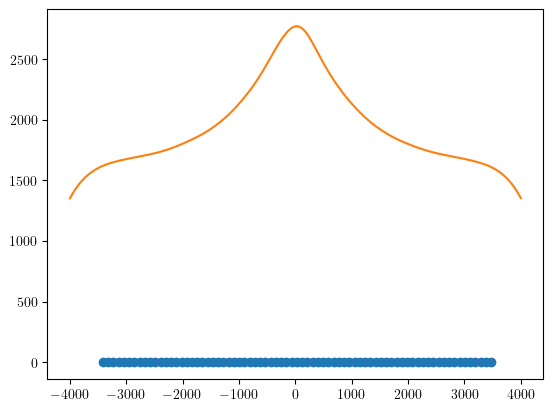

In [117]:
plt.scatter(cent, nphys)
plt.plot(vxs, model_phys , c='C1')

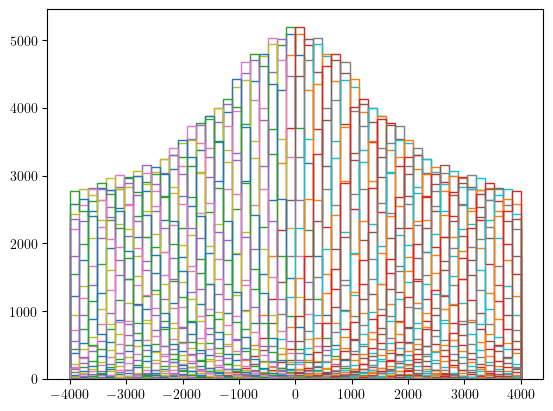

In [63]:
R_ind = 10
M_ind = 0
#ind = 30
#stacked_hists = np.zeros((100, 50))
for ind in range(100):
    velocities = vpeclos[ind + R_ind*len(rlos_cens) + M_ind*len(r_cens)*len(rlos_cens)] - a*H*rlos_data[ind + R_ind*len(rlos_cens) + M_ind*len(r_cens)*len(rlos_cens)]/h
    #velocities
    #LOS_vels = vphyslos[R_ind+M_ind*len(r_cens)]

    hist = plt.hist(velocities, bins=50, range=[-4000, 4000], histtype='step', density=False) 
    hist2 = plt.hist(-velocities, bins=50, range=[-4000, 4000], histtype='step', density=False) 
    #hist3 = plt.hist(LOS_vels, bins=50, range=[-4000, 4000], histtype='step', density=False) 
    #stacked_hists[ind, :] = hist[0]+hist2[0] 
    edg = hist[1]
    cents = 0.5*(edg[1:]+edg[:-1])

#plt.scatter(cents, np.sum(stacked_hists, axis=0))

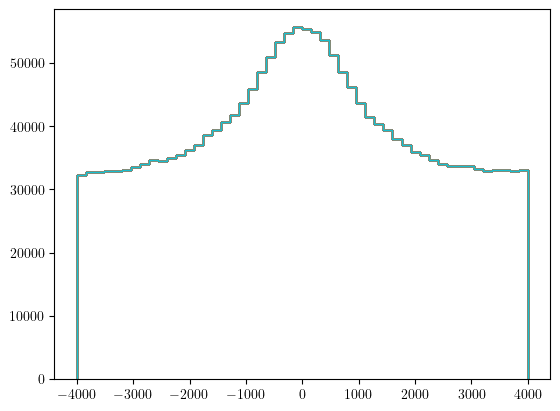

In [62]:
R_ind = 10
M_ind = 0
#ind = 30

for ind in range(100):    
    LOS_vels = vphyslos[R_ind+M_ind*len(r_cens)]

    hist3 = plt.hist(LOS_vels, bins=50, range=[-4000, 4000], histtype='step', density=False) 
    edg = hist[1]
    cents = 0.5*(edg[1:]+edg[:-1])


In [172]:
max(rxhg)

np.float64(46.442397464772355)

In [192]:
# check model with increased divisions along rlos

def P_vphys_R_vec(v_phys, R, M, pars):
    M = M * 1e14

    h = cosmo.h
    a = 0.83760
    redshift=1/a-1
    H = h*100*cosmo.Ez(redshift)

    # r_LOS integration range
    rlos_max = max(rxhg) #4000/a/H*h #max(rxhg) #100 #np.sqrt(max(rxhg)**2 - R**2)
    rlos_vals = np.linspace(0.0, rlos_max, 100) 

    # velocity grid for interpolation
    vr_grid = np.linspace(-4000, 4000, 200) 

    # Shape (n_v, n_r)
    vpec = v_phys[:, None] - a * H * rlos_vals[None, :] / h 
    
    # Compute P(vlos | R, rlos) for all rlos on vr_grid
    Pvlos_grid = np.array([P_vlos_R_rlos(vr_grid, R, rlos, M, pars) for rlos in rlos_vals])  
    # shape (n_r, n_v)

    # Interpolate along vr_grid axis for each rlos
    Pvlos_interp = np.array([
        np.interp(vpec[:, j], vr_grid, Pvlos_grid[j], left=None, right=None)
        for j in range(len(rlos_vals))
    ])  # shape (n_r, n_v)

    # Now shape (n_v, n_r)
    Pvlos_interp = Pvlos_interp.T  

    # Weight factor
    weight = 0.014 * (cf_inf(np.sqrt(R**2 + rlos_vals**2), M, cf_pars) + 1)  
    # shape (n_r,)

    # Multiply and integrate over rlos
    integrand = Pvlos_interp * weight[None, :]  
    P_out = np.trapz(integrand, rlos_vals, axis=1)  # shape (n_v,)

    # Normalize by Sigma(R)
    sigma_R = Sigma_inf(R, M, h, cf_pars)
    P_out /= sigma_R

    # Symmetrize
    dist = P_out + np.flip(P_out)

    return dist / dist.sum() / np.diff(v_phys)[0]

/tmp/ipykernel_938841/4208272057.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(np.trapz(jd, vr, dx=np.diff(vr)[0], axis=-2), vt, dx=np.diff(vt)[0], axis=-1)
/tmp/ipykernel_938841/4208272057.py:211: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out[i] = np.trapz(integrand, vr)
/tmp/ipykernel_938841/2127546731.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out = np.trapz(integrand, rlos_vals, axis=1)  # shape (n_v,)


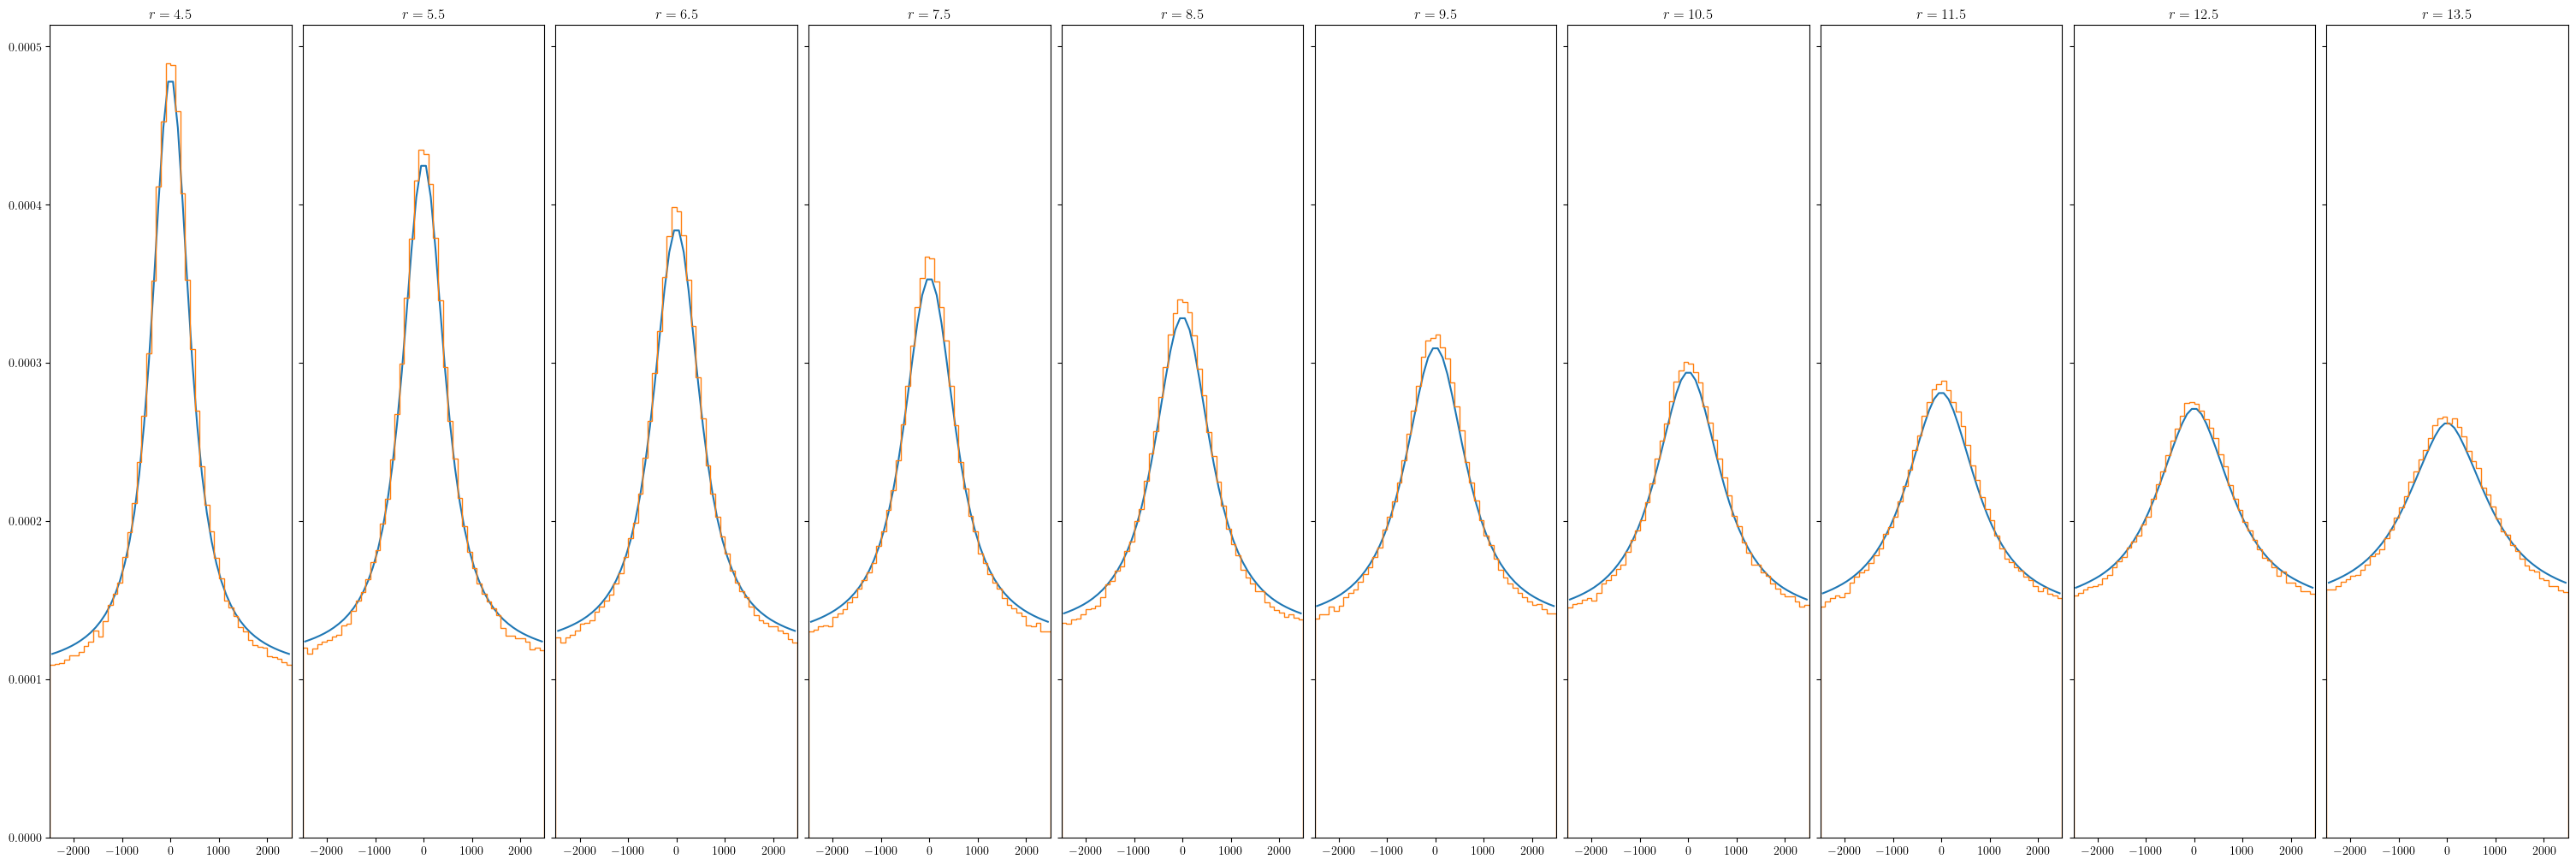

In [193]:
fig, ax = plt.subplots(1, len(r_cens[:10]), figsize=(30, 10), sharey=True, layout='constrained')

for i in range(len(r_cens[:10])):
    test = P_vphys_R_vec(vcens, r_cens[i], Mvirs[0]/1e14, gal_MAP)
    ax[i].plot(vcens, test)
    hist = ax[i].hist(vphyslos[i], bins=50, range=[-2500, 2500], histtype='step', density=True, color='C1')
    ax[i].margins(x=0)
    ax[i].set_title(f'$r={r_cens[i]}$') 

/tmp/ipykernel_938841/4208272057.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(np.trapz(jd, vr, dx=np.diff(vr)[0], axis=-2), vt, dx=np.diff(vt)[0], axis=-1)
/tmp/ipykernel_938841/4208272057.py:211: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out[i] = np.trapz(integrand, vr)
/tmp/ipykernel_938841/1420746098.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_out = np.trapz(integrand, rlos_vals, axis=1)  # shape (n_v,)


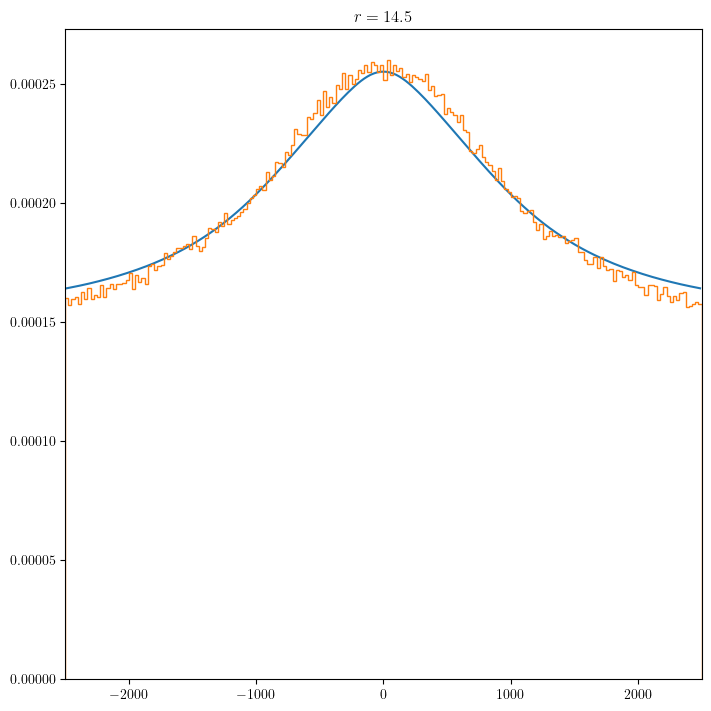

In [190]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7), sharey=True, layout='constrained')

test_e = np.linspace(-2500, 2500, 200)
test_cens = 0.5*(test_e[1:]+test_e[:-1])

for i in range(1):
    i = 10
    test = P_vphys_R_vec(test_cens, r_cens[i], Mvirs[0]/1e14, gal_MAP)
    ax.plot(test_cens, test)
    hist = ax.hist(vphyslos[i], bins=200, range=[-2500, 2500], histtype='step', density=True, color='C1')
    ax.margins(x=0)
    ax.set_title(f'$r={r_cens[i]}$') 

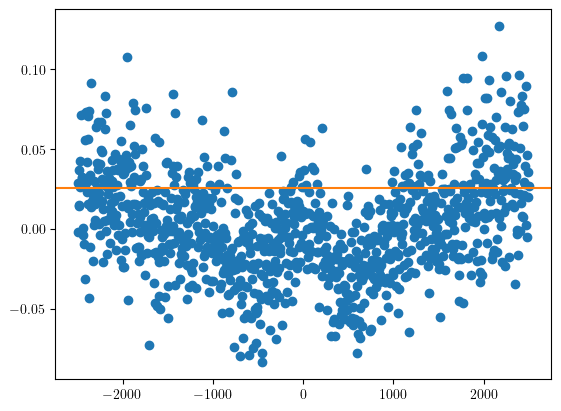

In [161]:
plt.scatter(test_cens, (test-hist[0][:-1])/hist[0][:-1])
plt.axhline(np.mean(np.abs((test-hist[0][:-1])/hist[0][:-1])), c='C1')

In [ ]:
np.mean(np.abs((test-hist[0][:-1])/hist[0][:-1])) # with 1_000 r_cens

np.float64(0.025860275971460504)

In [171]:
np.mean(np.abs((test-hist[0][:-1])/hist[0][:-1])) # with 500 r_cens

np.float64(0.018867916064345836)

In [191]:
np.mean(np.abs((test-hist[0][:-1])/hist[0][:-1])) # changing rlos_max

np.float64(0.018844206956226496)

In [177]:
2500*h /a/H

np.float64(27.071292011282416)